In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import pandas as pd
import xarray as xr
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

# Load Data

In [2]:
ds_sst1 = xr.open_dataset('/kaggle/input/notebooks/andreh19/10-1-3d-sst-missval/ds_wpp_sst_3d_clean.nc')
ds_sst = ds_sst1.drop_vars("sst")
ds_sst = ds_sst.rename({"sst_3ddineof": "sst"})
ds_sst

<xarray.Dataset> Size: 1GB
Dimensions:   (time: 496, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time      (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat       (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon       (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    qual_sst  (time, lat, lon) float32 350MB ...
    palette   (time, rgb, eightbitcolor) uint8 381kB ...
    sst       (time, lat, lon) float64 699MB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.SST...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        99152
    data_minimum:                     24.244999
    data_maximum:                     35.745

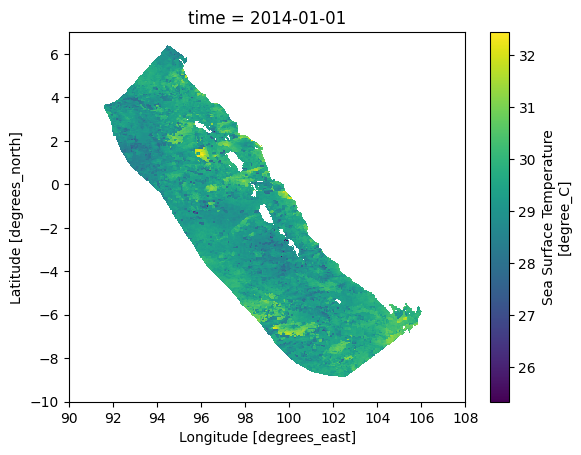

In [3]:
ds_sst['sst'].isel(time=0).plot()

In [4]:
with np.load('/kaggle/input/notebooks/andreh19/2-masking/mask_wpp572.npz') as data:
    mask_2d = data['mask_2d']
    lons = data['lons']
    lats = data['lats']

mask_2d

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(408, 432))

In [5]:
# Pastikan ds_sst sudah didefinisikan sebelumnya

print("--- Perulangan Selisih Koordinat Longitude ---")

for i in range(10, 0, -1):
    idx_sekarang = i
    idx_sebelumnya = i - 1
    
    # Mengambil nilai asli koordinat berdasarkan indeks
    val_sekarang = ds_sst['lon'][idx_sekarang].values
    val_sebelumnya = ds_sst['lon'][idx_sebelumnya].values
    
    # Menghitung selisihnya
    selisih = val_sekarang - val_sebelumnya
    
    # Mencetak hasil
    print(f"Indeks {idx_sekarang} ke {idx_sebelumnya} | Nilai: {val_sekarang:.4f} - {val_sebelumnya:.4f} = Selisih: {selisih:.6f}")

--- Perulangan Selisih Koordinat Longitude ---
Indeks 10 ke 9 | Nilai: 90.4375 - 90.3958 = Selisih: 0.041664
Indeks 9 ke 8 | Nilai: 90.3958 - 90.3542 = Selisih: 0.041672
Indeks 8 ke 7 | Nilai: 90.3542 - 90.3125 = Selisih: 0.041664
Indeks 7 ke 6 | Nilai: 90.3125 - 90.2708 = Selisih: 0.041664
Indeks 6 ke 5 | Nilai: 90.2708 - 90.2292 = Selisih: 0.041672
Indeks 5 ke 4 | Nilai: 90.2292 - 90.1875 = Selisih: 0.041664
Indeks 4 ke 3 | Nilai: 90.1875 - 90.1458 = Selisih: 0.041664
Indeks 3 ke 2 | Nilai: 90.1458 - 90.1042 = Selisih: 0.041672
Indeks 2 ke 1 | Nilai: 90.1042 - 90.0625 = Selisih: 0.041664
Indeks 1 ke 0 | Nilai: 90.0625 - 90.0208 = Selisih: 0.041664


In [6]:
# Pastikan ds_sst sudah didefinisikan sebelumnya

print("--- Perulangan Selisih Koordinat Lat ---")

for i in range(10, 0, -1):
    idx_sekarang = i
    idx_sebelumnya = i - 1
    
    # Mengambil nilai asli koordinat berdasarkan indeks
    val_sekarang = ds_sst['lat'][idx_sekarang].values
    val_sebelumnya = ds_sst['lat'][idx_sebelumnya].values
    
    # Menghitung selisihnya
    selisih = val_sekarang - val_sebelumnya
    
    # Mencetak hasil
    print(f"Indeks {idx_sekarang} ke {idx_sebelumnya} | Nilai: {val_sekarang:.4f} - {val_sebelumnya:.4f} = Selisih: {selisih:.6f}")

--- Perulangan Selisih Koordinat Lat ---
Indeks 10 ke 9 | Nilai: 6.5625 - 6.6042 = Selisih: -0.041667
Indeks 9 ke 8 | Nilai: 6.6042 - 6.6458 = Selisih: -0.041667
Indeks 8 ke 7 | Nilai: 6.6458 - 6.6875 = Selisih: -0.041667
Indeks 7 ke 6 | Nilai: 6.6875 - 6.7292 = Selisih: -0.041667
Indeks 6 ke 5 | Nilai: 6.7292 - 6.7708 = Selisih: -0.041667
Indeks 5 ke 4 | Nilai: 6.7708 - 6.8125 = Selisih: -0.041667
Indeks 4 ke 3 | Nilai: 6.8125 - 6.8542 = Selisih: -0.041667
Indeks 3 ke 2 | Nilai: 6.8542 - 6.8958 = Selisih: -0.041667
Indeks 2 ke 1 | Nilai: 6.8958 - 6.9375 = Selisih: -0.041667
Indeks 1 ke 0 | Nilai: 6.9375 - 6.9792 = Selisih: -0.041667


# Rata-rata jarak

In [7]:
# =========================
# 1. Ambil koordinat dari dataset
# =========================
lats = ds_sst["lat"].values
lons = ds_sst["lon"].values

# Pastikan mask sesuai dimensi lat-lon
assert mask_2d.shape == (len(lats), len(lons)), (
    f"Shape mask {mask_2d.shape} tidak sama dengan shape lat-lon "
    f"{(len(lats), len(lons))}"
)

# =========================
# 2. Fungsi haversine
# =========================
def haversine_km(lon1, lat1, lon2, lat2):
    """
    Menghitung jarak antar dua titik koordinat dalam kilometer.
    Bisa menerima skalar atau array.
    """
    R = 6371.0088  # radius bumi rata-rata dalam km

    lon1 = np.deg2rad(lon1)
    lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2)
    lat2 = np.deg2rad(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# =========================
# 3. Hitung jarak dari titik coastal ke semua titik valid dalam mask
# =========================
dist_from_coast = np.full(mask_2d.shape, np.nan)

rows = []

# Resolusi longitude rata-rata
dlon = np.nanmedian(np.abs(np.diff(lons)))

for i, lat in enumerate(lats):
    valid_j = np.where(mask_2d[i, :])[0]

    # Lewati latitude yang tidak memiliki area WPP
    if len(valid_j) < 2:
        continue

    valid_lons = lons[valid_j]

    # Untuk WPP 572, coastal dianggap sebagai longitude terbesar atau paling kanan
    j_coastal = valid_j[np.argmax(valid_lons)]
    lon_coastal = lons[j_coastal]

    # Offshore paling kiri dalam mask
    j_offshore_left = valid_j[np.argmin(valid_lons)]
    lon_offshore_left = lons[j_offshore_left]

    # Jarak dari coastal ke semua titik valid pada latitude yang sama
    dists = haversine_km(
        lon1=lon_coastal,
        lat1=lat,
        lon2=lons[valid_j],
        lat2=lat
    )

    dist_from_coast[i, valid_j] = dists

    # Jarak total dari coastal kanan ke offshore kiri
    transect_width_km = np.nanmax(dists)

    # Jarak grid longitude rata-rata pada latitude ini
    dx_grid_km = haversine_km(
        lon1=lon_coastal,
        lat1=lat,
        lon2=lon_coastal - dlon,
        lat2=lat
    )

    # Jarak antar titik valid dalam mask
    d_sorted = np.sort(dists)
    spacing_true = np.diff(d_sorted)

    rows.append({
        "lat": lat,
        "lon_coastal_right": lon_coastal,
        "lon_offshore_left": lon_offshore_left,
        "n_valid_pixel": len(valid_j),
        "transect_width_km": transect_width_km,
        "dx_grid_km": dx_grid_km,
        "mean_spacing_true_km": np.nanmean(spacing_true) if len(spacing_true) > 0 else np.nan,
        "median_spacing_true_km": np.nanmedian(spacing_true) if len(spacing_true) > 0 else np.nan
    })

df_dist_lat = pd.DataFrame(rows)

df_dist_lat.head()

,lat,lon_coastal_right,lon_offshore_left,n_valid_pixel,transect_width_km,dx_grid_km,mean_spacing_true_km,median_spacing_true_km
0,6.354167,94.562500,94.479164,3,9.209532,4.604388,4.604766,4.604766
1,6.312500,94.604164,94.437500,5,18.419796,4.604760,4.604949,4.604761
2,6.270833,94.687500,94.437500,7,27.632286,4.605129,4.605381,4.605130
3,6.229167,94.729164,94.395836,9,36.845474,4.605496,4.605684,4.605495
4,6.187500,94.812500,94.354164,12,50.667484,4.605860,4.606135,4.605862


Pada dataset ini 1 pixel ≈ 4.6 km.

| Variabel                 | Deskripsi                                                                                                                                                                                   |
| ------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `lat`                    | Nilai latitude pada satu baris grid. Untuk WPP NRI 572, setiap nilai `lat` dianggap sebagai satu transek horizontal dari pantai ke offshore.                                                |
| `lon_coastal_right`      | Longitude paling kanan dalam area `mask_2d == True` pada latitude tersebut. Dalam pendekatan ini, titik ini dianggap sebagai batas **coastal** atau titik paling dekat ke daratan Sumatera. |
| `lon_offshore_left`      | Longitude paling kiri dalam area `mask_2d == True` pada latitude tersebut. Titik ini dianggap sebagai batas offshore paling jauh ke arah barat dalam area WPP 572.                          |
| `n_valid_pixel`          | Jumlah piksel valid pada latitude tersebut yang berada di dalam area WPP 572. Nilai ini menunjukkan berapa banyak titik longitude yang tersedia dari coastal ke offshore.                   |
| `transect_width_km`      | Jarak total dari `lon_coastal_right` ke `lon_offshore_left` pada latitude yang sama. Ini menunjukkan lebar transek coastal-offshore dalam kilometer.                                        |
| `dx_grid_km`             | Jarak antar satu grid longitude pada latitude tersebut. Nilainya berubah sedikit antar latitude karena jarak 1° longitude bergantung pada posisi lintang.                                   |
| `mean_spacing_true_km`   | Rata-rata jarak antar piksel valid yang berurutan di dalam mask pada latitude tersebut. Nilai ini dihitung dari jarak antar titik valid setelah diurutkan dari coastal ke offshore.         |
| `median_spacing_true_km` | Median jarak antar piksel valid yang berurutan di dalam mask pada latitude tersebut. Nilai ini lebih stabil daripada rata-rata jika ada gap atau loncatan antar piksel dalam mask.          |


In [8]:
df_dist_lat[[
    "transect_width_km",
    "dx_grid_km",
    "mean_spacing_true_km",
    "median_spacing_true_km",
    "n_valid_pixel"
]].describe()

,transect_width_km,dx_grid_km,mean_spacing_true_km,median_spacing_true_km,n_valid_pixel
count,366.000000,366.000000,366.000000,366.000000,366.000000
mean,562.341125,4.618083,4.698508,4.618094,120.363388
std,195.611710,0.014483,0.138432,0.014489,40.917915
min,9.209532,4.577641,4.577922,4.577641,3.000000
25%,492.169350,4.609791,4.615037,4.609793,108.000000
50%,639.044281,4.622597,4.627910,4.622602,134.000000
75%,667.132034,4.630285,4.741225,4.630299,142.750000
max,871.406311,4.632849,5.461495,4.632874,185.000000


# Statistik Deskriptif SSTmin dan SSTmax

In [9]:
import numpy as np
import pandas as pd
import xarray as xr

# ============================================================
# 1. Ambil koordinat dan variabel SST
# ============================================================

sst_var = "sst"   # ganti ke "qual_sst" kalau yang mau dipakai adalah qual_sst

sst = ds_sst[sst_var]
times = ds_sst["time"].values
lats = ds_sst["lat"].values
lons = ds_sst["lon"].values

mask_2d = mask_2d.astype(bool)

print("SST shape :", sst.shape)
print("Mask shape:", mask_2d.shape)
print("Lat size  :", len(lats))
print("Lon size  :", len(lons))
print("Time size :", len(times))

# Validasi dimensi
assert sst.dims == ("time", "lat", "lon"), "Dimensi SST harus (time, lat, lon)."
assert mask_2d.shape == (len(lats), len(lons)), "Shape mask_2d tidak cocok dengan lat-lon ds_sst."


# ============================================================
# 2. Tentukan coastal longitude pada setiap latitude
#    Dalam kasus WPP 572: coast = longitude terbesar/rightmost
#    yang masih berada dalam inside WPP.
# ============================================================

lon_grid = np.broadcast_to(lons[None, :], mask_2d.shape)

# Jika satu baris latitude tidak punya area WPP, coastal_lon = NaN
coastal_lon_by_lat = np.where(
    mask_2d.any(axis=1),
    np.nanmax(np.where(mask_2d, lon_grid, np.nan), axis=1),
    np.nan
)

coast_df = pd.DataFrame({
    "lat": lats,
    "coastal_lon": coastal_lon_by_lat,
    "n_lon_inside_wpp": mask_2d.sum(axis=1)
})

print("\nContoh coastal longitude per latitude:")
display(coast_df.head())


# ============================================================
# 3. Masking SST: hanya area inside WPPNRI 572
# ============================================================

# Supaya broadcasting sesuai: mask_2d menjadi dimensi lat-lon
mask_da = xr.DataArray(
    mask_2d,
    coords={"lat": lats, "lon": lons},
    dims=("lat", "lon")
)

sst_wpp = sst.where(mask_da)

# Load ke numpy untuk operasi argmin/argmax yang eksplisit
# Ukuran data Anda sekitar time x 408 x 432, masih wajar untuk diproses.
sst_np = sst_wpp.values.astype(np.float64)  # shape: (time, lat, lon)

# Kalau SST ternyata Kelvin, aktifkan ini:
# if np.nanmean(sst_np) > 100:
#     sst_np = sst_np - 273.15


# ============================================================
# 4. Cari SSTmin dan SSTmax per time-lat
# ============================================================

valid = np.isfinite(sst_np)
valid_time_lat = valid.any(axis=2)  # True jika pada time-lat ada minimal satu lon valid

# Untuk argmin: NaN dibuat +inf agar tidak terpilih
sst_for_min = np.where(valid, sst_np, np.inf)
idx_min = np.argmin(sst_for_min, axis=2)

# Untuk argmax: NaN dibuat -inf agar tidak terpilih
sst_for_max = np.where(valid, sst_np, -np.inf)
idx_max = np.argmax(sst_for_max, axis=2)

# Ambil nilai SSTmin dan SSTmax
sst_min = np.take_along_axis(sst_np, idx_min[:, :, None], axis=2).squeeze(axis=2)
sst_max = np.take_along_axis(sst_np, idx_max[:, :, None], axis=2).squeeze(axis=2)

# Ambil longitude lokasi SSTmin dan SSTmax
lon_min = lons[idx_min]
lon_max = lons[idx_max]

# Untuk baris yang tidak valid, set NaN
sst_min = np.where(valid_time_lat, sst_min, np.nan)
sst_max = np.where(valid_time_lat, sst_max, np.nan)
lon_min = np.where(valid_time_lat, lon_min, np.nan)
lon_max = np.where(valid_time_lat, lon_max, np.nan)


# ============================================================
# 5. Hitung jarak SSTmin dan SSTmax dari coast
#    Karena pada WPP 572 offshore umumnya ke longitude lebih kecil,
#    distance positif dihitung sebagai coastal_lon - lon_point.
# ============================================================

R = 6371.0  # radius bumi dalam km

def signed_zonal_distance_km(lat_1d, coastal_lon_1d, point_lon_2d):
    """
    Menghitung jarak zonal dari coast ke titik pada latitude yang sama.
    Positif jika titik berada ke barat/offshore dari coast dalam kasus WPP 572:
    coastal_lon - point_lon > 0.
    
    lat_1d          : array lat, shape (n_lat,)
    coastal_lon_1d : array coastal lon per lat, shape (n_lat,)
    point_lon_2d   : array lon titik ekstrem, shape (n_time, n_lat)
    """
    lat_rad = np.deg2rad(lat_1d)[None, :]
    delta_lon_deg = coastal_lon_1d[None, :] - point_lon_2d
    
    # pendekatan zonal: 1 derajat longitude = 111.32*cos(lat) km
    dist_km = delta_lon_deg * 111.32 * np.cos(lat_rad)
    return dist_km

dist_min_km = signed_zonal_distance_km(lats, coastal_lon_by_lat, lon_min)
dist_max_km = signed_zonal_distance_km(lats, coastal_lon_by_lat, lon_max)

# Jika latitude tidak punya coastal lon valid, jadikan NaN
dist_min_km = np.where(np.isfinite(coastal_lon_by_lat)[None, :], dist_min_km, np.nan)
dist_max_km = np.where(np.isfinite(coastal_lon_by_lat)[None, :], dist_max_km, np.nan)

# Nilai UISST sementara, belum validasi coastal/offshore band
uisst_raw = sst_max - sst_min


# ============================================================
# 6. Bentuk tabel long format: setiap baris = 1 time x 1 latitude
# ============================================================

time_grid, lat_grid = np.meshgrid(times, lats, indexing="ij")
_, coastal_lon_grid = np.meshgrid(times, coastal_lon_by_lat, indexing="ij")

result_df = pd.DataFrame({
    "time": time_grid.ravel(),
    "lat": lat_grid.ravel(),
    "coastal_lon": coastal_lon_grid.ravel(),
    "sst_min": sst_min.ravel(),
    "lon_sst_min": lon_min.ravel(),
    "dist_sst_min_from_coast_km": dist_min_km.ravel(),
    "sst_max": sst_max.ravel(),
    "lon_sst_max": lon_max.ravel(),
    "dist_sst_max_from_coast_km": dist_max_km.ravel(),
    "uisst_raw_sstmax_minus_sstmin": uisst_raw.ravel()
})

# Hapus baris yang tidak punya data WPP valid
result_df = result_df.dropna(subset=["sst_min", "sst_max"]).reset_index(drop=True)

print("\nJumlah baris hasil:", len(result_df))
display(result_df.head())


# ============================================================
# 7. Statistik deskriptif keseluruhan
# ============================================================

cols_stat = [
    "sst_min",
    "sst_max",
    "dist_sst_min_from_coast_km",
    "dist_sst_max_from_coast_km",
    "uisst_raw_sstmax_minus_sstmin"
]

desc_overall = result_df[cols_stat].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

display(desc_overall)


# ============================================================
# 8. Statistik khusus jarak SSTmin dan SSTmax
#    Ini berguna untuk tahap awal menentukan kandidat coastal band
#    dan offshore band.
# ============================================================

distance_summary = pd.DataFrame({
    "metric": [
        "sst_min_distance_km",
        "sst_max_distance_km"
    ],
    "mean": [
        result_df["dist_sst_min_from_coast_km"].mean(),
        result_df["dist_sst_max_from_coast_km"].mean()
    ],
    "median": [
        result_df["dist_sst_min_from_coast_km"].median(),
        result_df["dist_sst_max_from_coast_km"].median()
    ],
    "p05": [
        result_df["dist_sst_min_from_coast_km"].quantile(0.05),
        result_df["dist_sst_max_from_coast_km"].quantile(0.05)
    ],
    "p25": [
        result_df["dist_sst_min_from_coast_km"].quantile(0.25),
        result_df["dist_sst_max_from_coast_km"].quantile(0.25)
    ],
    "p75": [
        result_df["dist_sst_min_from_coast_km"].quantile(0.75),
        result_df["dist_sst_max_from_coast_km"].quantile(0.75)
    ],
    "p90": [
        result_df["dist_sst_min_from_coast_km"].quantile(0.90),
        result_df["dist_sst_max_from_coast_km"].quantile(0.90)
    ],
    "p95": [
        result_df["dist_sst_min_from_coast_km"].quantile(0.95),
        result_df["dist_sst_max_from_coast_km"].quantile(0.95)
    ],
    "p99": [
        result_df["dist_sst_min_from_coast_km"].quantile(0.99),
        result_df["dist_sst_max_from_coast_km"].quantile(0.99)
    ],
    "min": [
        result_df["dist_sst_min_from_coast_km"].min(),
        result_df["dist_sst_max_from_coast_km"].min()
    ],
    "max": [
        result_df["dist_sst_min_from_coast_km"].max(),
        result_df["dist_sst_max_from_coast_km"].max()
    ],
})

display(distance_summary)


# ============================================================
# 9. Statistik per latitude
#    Untuk melihat apakah posisi SSTmin/SSTmax berbeda antar lintang.
# ============================================================

lat_summary = (
    result_df
    .groupby("lat")
    .agg(
        n_obs=("time", "count"),
        coastal_lon=("coastal_lon", "first"),
        sst_min_mean=("sst_min", "mean"),
        sst_min_median=("sst_min", "median"),
        sst_min_p05=("sst_min", lambda x: x.quantile(0.05)),
        sst_min_p95=("sst_min", lambda x: x.quantile(0.95)),
        dist_sst_min_mean_km=("dist_sst_min_from_coast_km", "mean"),
        dist_sst_min_median_km=("dist_sst_min_from_coast_km", "median"),
        dist_sst_min_p95_km=("dist_sst_min_from_coast_km", lambda x: x.quantile(0.95)),
        sst_max_mean=("sst_max", "mean"),
        sst_max_median=("sst_max", "median"),
        sst_max_p05=("sst_max", lambda x: x.quantile(0.05)),
        sst_max_p95=("sst_max", lambda x: x.quantile(0.95)),
        dist_sst_max_mean_km=("dist_sst_max_from_coast_km", "mean"),
        dist_sst_max_median_km=("dist_sst_max_from_coast_km", "median"),
        dist_sst_max_p95_km=("dist_sst_max_from_coast_km", lambda x: x.quantile(0.95)),
        uisst_raw_mean=("uisst_raw_sstmax_minus_sstmin", "mean"),
        uisst_raw_median=("uisst_raw_sstmax_minus_sstmin", "median")
    )
    .reset_index()
)

display(lat_summary.head())


# ============================================================
# 10. Simpan hasil ke CSV
# ============================================================

result_df.to_csv("sstmin_sstmax_distance_each_time_lat_wpp572.csv", index=False)
desc_overall.to_csv("descriptive_statistics_sstmin_sstmax_wpp572.csv")
distance_summary.to_csv("distance_summary_sstmin_sstmax_wpp572.csv", index=False)
lat_summary.to_csv("lat_summary_sstmin_sstmax_wpp572.csv", index=False)

print("File berhasil disimpan:")
print("- sstmin_sstmax_distance_each_time_lat_wpp572.csv")
print("- descriptive_statistics_sstmin_sstmax_wpp572.csv")
print("- distance_summary_sstmin_sstmax_wpp572.csv")
print("- lat_summary_sstmin_sstmax_wpp572.csv")

SST shape : (496, 408, 432)
Mask shape: (408, 432)
Lat size  : 408
Lon size  : 432
Time size : 496

Contoh coastal longitude per latitude:


/tmp/ipykernel_16/1137779117.py:40: RuntimeWarning: All-NaN slice encountered
  np.nanmax(np.where(mask_2d, lon_grid, np.nan), axis=1),


,lat,coastal_lon,n_lon_inside_wpp
0,6.979167,NaN,0
1,6.937500,NaN,0
2,6.895833,NaN,0
3,6.854167,NaN,0
4,6.812500,NaN,0



Jumlah baris hasil: 182032


,time,lat,coastal_lon,sst_min,lon_sst_min,dist_sst_min_from_coast_km,sst_max,lon_sst_max,dist_sst_max_from_coast_km,uisst_raw_sstmax_minus_sstmin
0,2014-01-01,6.395833,94.479164,28.845579,94.479164,0.000000,28.845579,94.479164,0.000000,0.000000
1,2014-01-01,6.354167,94.562500,28.826640,94.479164,9.219959,28.938605,94.562500,0.000000,0.111965
2,2014-01-01,6.312500,94.604164,28.285000,94.479164,13.830633,28.977702,94.604164,0.000000,0.692702
3,2014-01-01,6.270833,94.687500,28.285000,94.479164,23.053186,28.997856,94.645836,4.610299,0.712857
4,2014-01-01,6.229167,94.729164,28.334999,94.479164,27.665688,29.065538,94.562500,18.443512,0.730539


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
sst_min,182032.0,28.497199,1.108911,19.525000,24.955000,26.474998,27.314999,27.920000,28.564999,29.209999,29.779999,30.099998,30.699999,33.259998
sst_max,182032.0,30.992256,1.329387,25.664999,27.084999,28.599998,29.304998,30.189999,31.119999,31.934999,32.555000,32.889999,33.549999,37.445000
dist_sst_min_from_coast_km,182032.0,316.795166,206.019470,0.000000,0.000000,13.900630,41.597828,138.684570,301.490906,490.757721,602.979797,643.041809,746.423889,872.392456
dist_sst_max_from_coast_km,182032.0,193.153152,199.155716,0.000000,0.000000,0.000000,0.000000,32.081139,115.917206,310.757172,527.243896,607.830994,695.600586,872.392456
uisst_raw_sstmax_minus_sstmin,182032.0,2.495057,0.961455,0.000000,0.355000,0.972502,1.307541,1.865000,2.460001,3.084999,3.695002,4.104998,5.050001,9.450001


,metric,mean,median,p05,p25,p75,p90,p95,p99,min,max
0,sst_min_distance_km,316.795166,301.490906,13.90063,138.684570,490.757721,602.979797,643.041809,746.423889,0.0,872.392456
1,sst_max_distance_km,193.153152,115.917206,0.00000,32.081139,310.757172,527.243896,607.830994,695.600586,0.0,872.392456


,lat,n_obs,coastal_lon,sst_min_mean,sst_min_median,sst_min_p05,sst_min_p95,dist_sst_min_mean_km,dist_sst_min_median_km,dist_sst_min_p95_km,sst_max_mean,sst_max_median,sst_max_p05,sst_max_p95,dist_sst_max_mean_km,dist_sst_max_median_km,dist_sst_max_p95_km,uisst_raw_mean,uisst_raw_median
0,-8.854167,496,102.562500,28.207181,28.362499,25.858749,30.130000,17.389769,18.331961,36.664757,28.793814,28.934999,26.318749,30.901249,19.755220,20.623770,36.664757,0.586632,0.501406
1,-8.812500,496,102.645836,28.007289,28.147500,25.744999,29.825099,48.192501,45.836338,96.255135,28.996392,29.167780,26.436249,31.184999,50.872421,50.419636,96.255135,0.989103,0.900000
2,-8.770834,496,102.687500,27.949524,28.075000,25.658750,29.773749,62.153290,64.177582,123.770515,29.062683,29.222499,26.491249,31.229999,66.737381,68.761391,123.770515,1.113160,1.020000
3,-8.729167,496,102.729164,27.943471,28.080000,25.678750,29.721249,73.880272,75.645584,146.706848,29.081461,29.205000,26.534999,31.121250,74.555038,73.353424,146.706848,1.137990,1.050000
4,-8.687500,496,102.812500,27.878677,28.042500,25.674999,29.674999,84.917099,82.532104,169.649063,29.130150,29.247499,26.563749,31.243750,90.278740,93.995041,174.234726,1.251473,1.133028


File berhasil disimpan:
- sstmin_sstmax_distance_each_time_lat_wpp572.csv
- descriptive_statistics_sstmin_sstmax_wpp572.csv
- distance_summary_sstmin_sstmax_wpp572.csv
- lat_summary_sstmin_sstmax_wpp572.csv


In [10]:
import numpy as np
import pandas as pd

# ============================================================
# Threshold berdasarkan median jarak SSTmin
# ============================================================

THRESHOLD_KM = 500

# ============================================================
# Pastikan kolom yang dibutuhkan tersedia
# ============================================================

required_cols = [
    "time",
    "lat",
    "dist_sst_min_from_coast_km",
    "dist_sst_max_from_coast_km"
]

missing_cols = [col for col in required_cols if col not in result_df.columns]

if missing_cols:
    raise ValueError(f"Kolom berikut belum ada di result_df: {missing_cols}")

# ============================================================
# Buat status valid
# ============================================================

result_df["sstmin_valid"] = (
    result_df["dist_sst_min_from_coast_km"] <= THRESHOLD_KM
)

result_df["sstmax_valid"] = (
    result_df["dist_sst_max_from_coast_km"] > THRESHOLD_KM
)

result_df["time_lat_valid"] = (
    result_df["sstmin_valid"] & result_df["sstmax_valid"]
)

# ============================================================
# Hitung jumlah observasi valid
# ============================================================

total_obs = len(result_df)

n_sstmin_valid = result_df["sstmin_valid"].sum()
n_sstmax_valid = result_df["sstmax_valid"].sum()
n_time_lat_valid = result_df["time_lat_valid"].sum()

summary_count = pd.DataFrame({
    "metric": [
        "total_time_lat_observation",
        "sstmin_valid_count",
        "sstmax_valid_count",
        "sstmin_and_sstmax_valid_count"
    ],
    "count": [
        total_obs,
        n_sstmin_valid,
        n_sstmax_valid,
        n_time_lat_valid
    ],
    "percentage": [
        100.0,
        n_sstmin_valid / total_obs * 100,
        n_sstmax_valid / total_obs * 100,
        n_time_lat_valid / total_obs * 100
    ]
})

display(summary_count)

# ============================================================
# Hitung jumlah latitude valid
# Definisi: latitude valid jika minimal punya 1 waktu yang memenuhi
# SSTmin valid dan SSTmax valid sekaligus.
# ============================================================

lat_valid_summary = (
    result_df
    .groupby("lat")
    .agg(
        n_time=("time", "count"),
        n_sstmin_valid=("sstmin_valid", "sum"),
        n_sstmax_valid=("sstmax_valid", "sum"),
        n_time_lat_valid=("time_lat_valid", "sum")
    )
    .reset_index()
)

lat_valid_summary["latitude_valid"] = lat_valid_summary["n_time_lat_valid"] > 0

n_total_lat = result_df["lat"].nunique()
n_lat_valid = lat_valid_summary["latitude_valid"].sum()
n_lat_not_valid = n_total_lat - n_lat_valid

latitude_count_summary = pd.DataFrame({
    "metric": [
        "total_latitude",
        "valid_latitude",
        "not_valid_latitude"
    ],
    "count": [
        n_total_lat,
        n_lat_valid,
        n_lat_not_valid
    ],
    "percentage": [
        100.0,
        n_lat_valid / n_total_lat * 100,
        n_lat_not_valid / n_total_lat * 100
    ]
})

display(latitude_count_summary)

# ============================================================
# Tampilkan latitude yang valid
# ============================================================

valid_latitudes = lat_valid_summary[
    lat_valid_summary["latitude_valid"]
].copy()

display(valid_latitudes.head())

# ============================================================
# Tampilkan latitude yang tidak pernah valid
# ============================================================

invalid_latitudes = lat_valid_summary[
    ~lat_valid_summary["latitude_valid"]
].copy()

display(invalid_latitudes.head())

# ============================================================
# Simpan output
# ============================================================

result_df.to_csv("sstmin_sstmax_validity_threshold_301km_all_time_lat.csv", index=False)
summary_count.to_csv("sstmin_sstmax_validity_count_summary.csv", index=False)
latitude_count_summary.to_csv("latitude_validity_count_summary.csv", index=False)
lat_valid_summary.to_csv("latitude_validity_detail_summary.csv", index=False)

print("File berhasil disimpan:")
print("- sstmin_sstmax_validity_threshold_301km_all_time_lat.csv")
print("- sstmin_sstmax_validity_count_summary.csv")
print("- latitude_validity_count_summary.csv")
print("- latitude_validity_detail_summary.csv")

,metric,count,percentage
0,total_time_lat_observation,182032,100.000000
1,sstmin_valid_count,138611,76.146502
2,sstmax_valid_count,21251,11.674321
3,sstmin_and_sstmax_valid_count,17360,9.536785


,metric,count,percentage
0,total_latitude,367,100.000000
1,valid_latitude,273,74.386921
2,not_valid_latitude,94,25.613079


,lat,n_time,n_sstmin_valid,n_sstmax_valid,n_time_lat_valid,latitude_valid
30,-7.604167,496,483,22,22,True
31,-7.562500,496,471,36,36,True
32,-7.520834,496,461,44,44,True
33,-7.479167,496,458,60,59,True
34,-7.437500,496,444,63,63,True


,lat,n_time,n_sstmin_valid,n_sstmax_valid,n_time_lat_valid,latitude_valid
0,-8.854167,496,496,0,0,False
1,-8.812500,496,496,0,0,False
2,-8.770834,496,496,0,0,False
3,-8.729167,496,496,0,0,False
4,-8.687500,496,496,0,0,False


File berhasil disimpan:
- sstmin_sstmax_validity_threshold_301km_all_time_lat.csv
- sstmin_sstmax_validity_count_summary.csv
- latitude_validity_count_summary.csv
- latitude_validity_detail_summary.csv


In [11]:
import numpy as np
import pandas as pd

thresholds = [25,50,75, 100, 150, 200, 250, 300, 301.490906, 350, 400, 450, 500, 600]

rows = []

for th in thresholds:
    sstmin_valid = result_df["dist_sst_min_from_coast_km"] <= th
    sstmax_valid = result_df["dist_sst_max_from_coast_km"] > th
    both_valid = sstmin_valid & sstmax_valid
    
    n_total = len(result_df)
    n_lat_total = result_df["lat"].nunique()
    n_lat_valid = result_df.loc[both_valid, "lat"].nunique()
    
    rows.append({
        "threshold_km": th,
        "sstmin_valid_count": int(sstmin_valid.sum()),
        "sstmin_valid_pct": sstmin_valid.mean() * 100,
        "sstmax_valid_count": int(sstmax_valid.sum()),
        "sstmax_valid_pct": sstmax_valid.mean() * 100,
        "both_valid_count": int(both_valid.sum()),
        "both_valid_pct": both_valid.mean() * 100,
        "valid_latitude_count": int(n_lat_valid),
        "valid_latitude_pct": n_lat_valid / n_lat_total * 100
    })

threshold_eval = pd.DataFrame(rows)
display(threshold_eval)

threshold_eval.to_csv("threshold_sensitivity_analysis_uisst.csv", index=False)

,threshold_km,sstmin_valid_count,sstmin_valid_pct,sstmax_valid_count,sstmax_valid_pct,both_valid_count,both_valid_pct,valid_latitude_count,valid_latitude_pct
0,25.000000,12785,7.023490,139717,76.754087,9809,5.388613,364,99.182561
1,50.000000,19934,10.950822,124406,68.342929,13570,7.454733,361,98.365123
2,75.000000,27450,15.079766,108624,59.673025,16509,9.069285,358,97.547684
3,100.000000,33897,18.621451,97743,53.695504,18543,10.186670,355,96.730245
4,150.000000,49050,26.945812,80133,44.021381,22128,12.156104,348,94.822888
5,200.000000,63980,35.147666,67542,37.104465,24373,13.389404,332,90.463215
6,250.000000,77496,42.572734,56506,31.041795,25006,13.737145,320,87.193460
7,300.000000,90107,49.500637,47483,26.084974,24925,13.692647,310,84.468665
8,301.490906,91022,50.003296,46926,25.778984,24948,13.705283,310,84.468665
9,350.000000,102855,56.503802,39724,21.822537,24071,13.223499,301,82.016349


In [12]:
import pandas as pd
import numpy as np

# Pastikan time berbentuk datetime
result_df["time"] = pd.to_datetime(result_df["time"])

# Threshold terbaik dari sensitivity analysis
THRESHOLD_KM = 250.0

result_df["sstmin_valid"] = result_df["dist_sst_min_from_coast_km"] <= THRESHOLD_KM
result_df["sstmax_valid"] = result_df["dist_sst_max_from_coast_km"] > THRESHOLD_KM
result_df["time_lat_valid"] = result_df["sstmin_valid"] & result_df["sstmax_valid"]

result_df["year"] = result_df["time"].dt.year
result_df["month"] = result_df["time"].dt.month

# ============================================================
# 1. Representasi per tahun
# ============================================================

yearly_coverage = (
    result_df
    .groupby("year")
    .agg(
        total_obs=("time_lat_valid", "count"),
        valid_obs=("time_lat_valid", "sum"),
        valid_latitude=("lat", lambda x: result_df.loc[x.index[result_df.loc[x.index, "time_lat_valid"]], "lat"].nunique()),
        total_latitude=("lat", "nunique")
    )
    .reset_index()
)

yearly_coverage["valid_pct"] = yearly_coverage["valid_obs"] / yearly_coverage["total_obs"] * 100
yearly_coverage["valid_latitude_pct"] = yearly_coverage["valid_latitude"] / yearly_coverage["total_latitude"] * 100

display(yearly_coverage)

# ============================================================
# 2. Representasi per bulan
# ============================================================

monthly_coverage = (
    result_df
    .groupby("month")
    .agg(
        total_obs=("time_lat_valid", "count"),
        valid_obs=("time_lat_valid", "sum"),
        valid_latitude=("lat", lambda x: result_df.loc[x.index[result_df.loc[x.index, "time_lat_valid"]], "lat"].nunique()),
        total_latitude=("lat", "nunique")
    )
    .reset_index()
)

monthly_coverage["valid_pct"] = monthly_coverage["valid_obs"] / monthly_coverage["total_obs"] * 100
monthly_coverage["valid_latitude_pct"] = monthly_coverage["valid_latitude"] / monthly_coverage["total_latitude"] * 100

display(monthly_coverage)

# ============================================================
# 3. Representasi kombinasi tahun-bulan
# ============================================================

year_month_coverage = (
    result_df
    .groupby(["year", "month"])
    .agg(
        total_obs=("time_lat_valid", "count"),
        valid_obs=("time_lat_valid", "sum"),
        valid_latitude=("lat", lambda x: result_df.loc[x.index[result_df.loc[x.index, "time_lat_valid"]], "lat"].nunique()),
        total_latitude=("lat", "nunique")
    )
    .reset_index()
)

year_month_coverage["valid_pct"] = year_month_coverage["valid_obs"] / year_month_coverage["total_obs"] * 100
year_month_coverage["valid_latitude_pct"] = year_month_coverage["valid_latitude"] / year_month_coverage["total_latitude"] * 100

display(year_month_coverage)

# ============================================================
# 4. Ringkasan apakah representatif atau tidak
# ============================================================

summary_repr = pd.DataFrame({
    "metric": [
        "overall_valid_pct",
        "min_yearly_valid_pct",
        "max_yearly_valid_pct",
        "mean_yearly_valid_pct",
        "min_monthly_valid_pct",
        "max_monthly_valid_pct",
        "mean_monthly_valid_pct",
        "number_of_years",
        "number_of_months"
    ],
    "value": [
        result_df["time_lat_valid"].mean() * 100,
        yearly_coverage["valid_pct"].min(),
        yearly_coverage["valid_pct"].max(),
        yearly_coverage["valid_pct"].mean(),
        monthly_coverage["valid_pct"].min(),
        monthly_coverage["valid_pct"].max(),
        monthly_coverage["valid_pct"].mean(),
        yearly_coverage["year"].nunique(),
        monthly_coverage["month"].nunique()
    ]
})

display(summary_repr)

# Simpan output
yearly_coverage.to_csv("uisst_valid_coverage_by_year.csv", index=False)
monthly_coverage.to_csv("uisst_valid_coverage_by_month.csv", index=False)
year_month_coverage.to_csv("uisst_valid_coverage_by_year_month.csv", index=False)
summary_repr.to_csv("uisst_valid_representativeness_summary.csv", index=False)

,year,total_obs,valid_obs,valid_latitude,total_latitude,valid_pct,valid_latitude_pct
0,2014,16515,1980,313,367,11.989101,85.286104
1,2015,16882,2548,320,367,15.092998,87.193460
2,2016,15781,1924,320,367,12.191876,87.193460
3,2017,15781,1738,315,367,11.013244,85.831063
4,2018,16515,2153,314,367,13.036633,85.558583
5,2019,16515,3211,317,367,19.442931,86.376022
6,2020,16515,2289,319,367,13.860127,86.920981
7,2021,16882,1799,316,367,10.656320,86.103542
8,2022,16515,2321,319,367,14.053890,86.920981
9,2023,16882,2956,317,367,17.509774,86.376022


,month,total_obs,valid_obs,valid_latitude,total_latitude,valid_pct,valid_latitude_pct
0,1,15781,2218,317,367,14.054876,86.376022
1,2,16148,2269,312,367,14.051276,85.013624
2,3,16148,2598,320,367,16.088680,87.193460
3,4,12845,2171,320,367,16.901518,87.193460
4,5,14313,2024,315,367,14.140991,85.831063
5,6,15781,1527,303,367,9.676193,82.561308
6,7,16148,1749,310,367,10.831063,84.468665
7,8,15047,2051,311,367,13.630624,84.741144
8,9,16148,2092,299,367,12.955165,81.471390
9,10,13212,1969,318,367,14.903118,86.648501


,year,month,total_obs,valid_obs,valid_latitude,total_latitude,valid_pct,valid_latitude_pct
0,2014,1,1468,200,157,367,13.623978,42.779292
1,2014,2,1468,191,144,367,13.010899,39.237057
2,2014,3,1468,399,216,367,27.179837,58.855586
3,2014,4,1101,186,142,367,16.893733,38.692098
4,2014,5,1468,254,201,367,17.302452,54.768392
...,...,...,...,...,...,...,...,...
128,2024,9,1468,121,102,367,8.242507,27.792916
129,2024,10,1468,84,83,367,5.722071,22.615804
130,2024,11,1101,205,172,367,18.619437,46.866485
131,2024,12,1468,113,94,367,7.697548,25.613079


,metric,value
0,overall_valid_pct,13.737145
1,min_yearly_valid_pct,4.632153
2,max_yearly_valid_pct,19.442931
3,mean_yearly_valid_pct,12.978386
4,min_monthly_valid_pct,9.676193
5,max_monthly_valid_pct,16.901518
6,mean_monthly_valid_pct,13.806634
7,number_of_years,12.000000
8,number_of_months,12.000000


## Penentuan Threshold Offshore dan Coastal

In [13]:
import numpy as np
import pandas as pd
import xarray as xr

# ============================================================
# 1. Parameter awal
# ============================================================

sst_var = "sst"   # ganti kalau nama variabel SST berbeda
thresholds = [25, 50, 75, 100, 150, 200, 250, 300, 301.490906,301.7, 302,302.5,303, 305,306,306.1, 306.2,306.3, 306.4,306.5,307,308,310, 316, 350, 400, 450, 500, 600]

sst = ds_sst[sst_var].transpose("time", "lat", "lon")

times = ds_sst["time"].values
lats = ds_sst["lat"].values
lons = ds_sst["lon"].values

mask_2d = mask_2d.astype(bool)

assert mask_2d.shape == (len(lats), len(lons)), "Shape mask_2d tidak sesuai dengan dimensi lat-lon."

print("SST shape :", sst.shape)
print("Mask shape:", mask_2d.shape)
print("Time size :", len(times))
print("Lat size  :", len(lats))
print("Lon size  :", len(lons))


# ============================================================
# 2. Tentukan coastal longitude per latitude
#    Asumsi WPP 572:
#    longitude terbesar/rightmost inside WPP = coast Sumatra
# ============================================================

lon_grid_2d = np.broadcast_to(lons[None, :], mask_2d.shape)

coastal_lon_by_lat = np.where(
    mask_2d.any(axis=1),
    np.nanmax(np.where(mask_2d, lon_grid_2d, np.nan), axis=1),
    np.nan
)


# ============================================================
# 3. Hitung distance_to_coast_km untuk semua grid
#    Positif jika titik berada ke arah offshore/barat
# ============================================================

lat_rad_2d = np.deg2rad(lats[:, None])

distance_to_coast_km_2d = (
    (coastal_lon_by_lat[:, None] - lons[None, :])
    * 111.32
    * np.cos(lat_rad_2d)
)

valid_wpp_2d = (
    mask_2d
    & np.isfinite(distance_to_coast_km_2d)
    & (distance_to_coast_km_2d >= 0)
)

total_grid_inside_wpp = int(valid_wpp_2d.sum())

print("Total grid inside WPP:", total_grid_inside_wpp)


# ============================================================
# 4. Buat DataArray mask dan valid SST
# ============================================================

valid_wpp_da = xr.DataArray(
    valid_wpp_2d,
    coords={"lat": lats, "lon": lons},
    dims=("lat", "lon")
)

# Data SST valid di dalam WPP
valid_sst_da = sst.notnull() & valid_wpp_da

total_valid_sst_obs = int(valid_sst_da.sum().values)

print("Total valid SST observation inside WPP:", total_valid_sst_obs)


# ============================================================
# 5. Evaluasi setiap threshold
# ============================================================

rows = []

for th in thresholds:
    coastal_band_2d = valid_wpp_2d & (distance_to_coast_km_2d <= th)
    offshore_band_2d = valid_wpp_2d & (distance_to_coast_km_2d > th)
    
    coastal_band_da = xr.DataArray(
        coastal_band_2d,
        coords={"lat": lats, "lon": lons},
        dims=("lat", "lon")
    )
    
    offshore_band_da = xr.DataArray(
        offshore_band_2d,
        coords={"lat": lats, "lon": lons},
        dims=("lat", "lon")
    )
    
    # Jumlah grid statis
    coastal_grid_count = int(coastal_band_2d.sum())
    offshore_grid_count = int(offshore_band_2d.sum())
    
    # Jumlah observasi SST valid sepanjang semua timestamp
    coastal_valid_obs = int((valid_sst_da & coastal_band_da).sum().values)
    offshore_valid_obs = int((valid_sst_da & offshore_band_da).sum().values)
    
    # Latitude yang memiliki minimal satu grid coastal/offshore
    coastal_lat_count = int((coastal_band_2d.sum(axis=1) > 0).sum())
    offshore_lat_count = int((offshore_band_2d.sum(axis=1) > 0).sum())
    both_band_lat_count = int(
        ((coastal_band_2d.sum(axis=1) > 0) & (offshore_band_2d.sum(axis=1) > 0)).sum()
    )
    
    # Persentase grid
    coastal_grid_pct = coastal_grid_count / total_grid_inside_wpp * 100
    offshore_grid_pct = offshore_grid_count / total_grid_inside_wpp * 100
    
    # Persentase observasi SST
    coastal_obs_pct = coastal_valid_obs / total_valid_sst_obs * 100
    offshore_obs_pct = offshore_valid_obs / total_valid_sst_obs * 100
    
    # Ukuran keseimbangan
    abs_diff_obs_pct = abs(coastal_obs_pct - offshore_obs_pct)
    
    if max(coastal_valid_obs, offshore_valid_obs) > 0:
        balance_ratio = min(coastal_valid_obs, offshore_valid_obs) / max(coastal_valid_obs, offshore_valid_obs)
    else:
        balance_ratio = np.nan
    
    rows.append({
        "threshold_km": th,
        
        "coastal_grid_count": coastal_grid_count,
        "offshore_grid_count": offshore_grid_count,
        "coastal_grid_pct": coastal_grid_pct,
        "offshore_grid_pct": offshore_grid_pct,
        
        "coastal_valid_sst_obs": coastal_valid_obs,
        "offshore_valid_sst_obs": offshore_valid_obs,
        "coastal_valid_sst_pct": coastal_obs_pct,
        "offshore_valid_sst_pct": offshore_obs_pct,
        
        "abs_diff_valid_sst_pct": abs_diff_obs_pct,
        "balance_ratio": balance_ratio,
        
        "coastal_lat_count": coastal_lat_count,
        "offshore_lat_count": offshore_lat_count,
        "both_band_lat_count": both_band_lat_count,
    })

threshold_band_balance = pd.DataFrame(rows)

# Urutkan berdasarkan keseimbangan terbaik:
# abs_diff paling kecil dan balance_ratio paling besar.
threshold_band_balance_sorted = (
    threshold_band_balance
    .sort_values(["abs_diff_valid_sst_pct", "balance_ratio"], ascending=[True, False])
    .reset_index(drop=True)
)

display(threshold_band_balance)
display(threshold_band_balance_sorted)


# ============================================================
# 6. Threshold terbaik berdasarkan jumlah data paling seimbang
# ============================================================

best_threshold = threshold_band_balance_sorted.iloc[0]

print("Threshold paling seimbang berdasarkan valid SST observation:")
print("Threshold km              :", best_threshold["threshold_km"])
print("Coastal valid SST pct     :", best_threshold["coastal_valid_sst_pct"])
print("Offshore valid SST pct    :", best_threshold["offshore_valid_sst_pct"])
print("Absolute difference pct   :", best_threshold["abs_diff_valid_sst_pct"])
print("Balance ratio             :", best_threshold["balance_ratio"])
print("Both band latitude count  :", int(best_threshold["both_band_lat_count"]))


# ============================================================
# 7. Simpan hasil
# ============================================================

threshold_band_balance.to_csv("threshold_band_balance_all_sst_wpp572.csv", index=False)
threshold_band_balance_sorted.to_csv("threshold_band_balance_sorted_wpp572.csv", index=False)

print("File berhasil disimpan:")
print("- threshold_band_balance_all_sst_wpp572.csv")
print("- threshold_band_balance_sorted_wpp572.csv")

SST shape : (496, 408, 432)
Mask shape: (408, 432)
Time size : 496
Lat size  : 408
Lon size  : 432
Total grid inside WPP: 44054


/tmp/ipykernel_16/269319533.py:39: RuntimeWarning: All-NaN slice encountered
  np.nanmax(np.where(mask_2d, lon_grid_2d, np.nan), axis=1),


Total valid SST observation inside WPP: 21850784


,threshold_km,coastal_grid_count,offshore_grid_count,coastal_grid_pct,offshore_grid_pct,coastal_valid_sst_obs,offshore_valid_sst_obs,coastal_valid_sst_pct,offshore_valid_sst_pct,abs_diff_valid_sst_pct,balance_ratio,coastal_lat_count,offshore_lat_count,both_band_lat_count
0,25.000000,2144,41910,4.866754,95.133246,1063424,20787360,4.866754,95.133246,90.266491,0.051157,367,364,364
1,50.000000,3901,40153,8.855042,91.144958,1934896,19915888,8.855042,91.144958,82.289917,0.097153,367,361,361
2,75.000000,6036,38018,13.701367,86.298633,2993856,18856928,13.701367,86.298633,72.597267,0.158767,367,358,358
3,100.000000,7778,36276,17.655604,82.344396,3857888,17992896,17.655604,82.344396,64.688791,0.214412,367,355,355
4,150.000000,11353,32701,25.770645,74.229355,5631088,16219696,25.770645,74.229355,48.458710,0.347176,367,348,348
5,200.000000,14719,29335,33.411268,66.588732,7300624,14550160,33.411268,66.588732,33.177464,0.501756,367,332,332
6,250.000000,18119,25935,41.129069,58.870931,8987024,12863760,41.129069,58.870931,17.741862,0.698631,367,320,320
7,300.000000,21508,22546,48.821900,51.178100,10667968,11182816,48.821900,51.178100,2.356199,0.953961,367,310,310
8,301.490906,21751,22303,49.373496,50.626504,10788496,11062288,49.373496,50.626504,1.253008,0.975250,367,310,310
9,301.700000,21755,22299,49.382576,50.617424,10790480,11060304,49.382576,50.617424,1.234848,0.975604,367,310,310


,threshold_km,coastal_grid_count,offshore_grid_count,coastal_grid_pct,offshore_grid_pct,coastal_valid_sst_obs,offshore_valid_sst_obs,coastal_valid_sst_pct,offshore_valid_sst_pct,abs_diff_valid_sst_pct,balance_ratio,coastal_lat_count,offshore_lat_count,both_band_lat_count
0,306.100000,22027,22027,50.000000,50.000000,10925392,10925392,50.000000,50.000000,0.000000,1.000000,367,309,309
1,306.200000,22065,21989,50.086258,49.913742,10944240,10906544,50.086258,49.913742,0.172516,0.996556,367,309,309
2,306.300000,22065,21989,50.086258,49.913742,10944240,10906544,50.086258,49.913742,0.172516,0.996556,367,309,309
3,306.400000,22065,21989,50.086258,49.913742,10944240,10906544,50.086258,49.913742,0.172516,0.996556,367,309,309
4,306.500000,22065,21989,50.086258,49.913742,10944240,10906544,50.086258,49.913742,0.172516,0.996556,367,309,309
5,307.000000,22065,21989,50.086258,49.913742,10944240,10906544,50.086258,49.913742,0.172516,0.996556,367,309,309
6,306.000000,21985,22069,49.904662,50.095338,10904560,10946224,49.904662,50.095338,0.190675,0.996194,367,309,309
7,308.000000,22081,21973,50.122577,49.877423,10952176,10898608,50.122577,49.877423,0.245154,0.995109,367,308,308
8,310.000000,22180,21874,50.347301,49.652699,11001280,10849504,50.347301,49.652699,0.694602,0.986204,367,308,308
9,305.000000,21837,22217,49.568711,50.431289,10831152,11019632,49.568711,50.431289,0.862578,0.982896,367,310,310


Threshold paling seimbang berdasarkan valid SST observation:
Threshold km              : 306.1
Coastal valid SST pct     : 50.0
Offshore valid SST pct    : 50.0
Absolute difference pct   : 0.0
Balance ratio             : 1.0
Both band latitude count  : 309
File berhasil disimpan:
- threshold_band_balance_all_sst_wpp572.csv
- threshold_band_balance_sorted_wpp572.csv


## 50:50 ratio

In [14]:
import numpy as np
import pandas as pd
import xarray as xr

# ============================================================
# 1. Ambil koordinat
# ============================================================

lats = ds_sst["lat"].values
lons = ds_sst["lon"].values
mask_2d = mask_2d.astype(bool)

assert mask_2d.shape == (len(lats), len(lons)), "Shape mask_2d tidak cocok dengan lat-lon."

# ============================================================
# 2. Tentukan titik coast per latitude
#    Asumsi WPP 572: longitude terbesar/rightmost inside WPP = coast Sumatra
# ============================================================

lon_grid_2d = np.broadcast_to(lons[None, :], mask_2d.shape)

coastal_lon_by_lat = np.where(
    mask_2d.any(axis=1),
    np.nanmax(np.where(mask_2d, lon_grid_2d, np.nan), axis=1),
    np.nan
)

# ============================================================
# 3. Hitung jarak setiap grid dari coast
#    Positif jika titik makin ke offshore/barat
# ============================================================

lat_rad_2d = np.deg2rad(lats[:, None])

distance_to_coast_km_2d = (
    (coastal_lon_by_lat[:, None] - lons[None, :])
    * 111.32
    * np.cos(lat_rad_2d)
)

valid_wpp_2d = (
    mask_2d
    & np.isfinite(distance_to_coast_km_2d)
    & (distance_to_coast_km_2d >= 0)
)

dist_valid = distance_to_coast_km_2d[valid_wpp_2d]
dist_valid = dist_valid[np.isfinite(dist_valid)]

print("Total valid grid inside WPP:", len(dist_valid))

# ============================================================
# 4. Hitung threshold 50:50
#    Definisi:
#    threshold dipilih sebagai nilai jarak yang membuat
#    jumlah grid <= threshold sama/semendekati mungkin
#    dengan jumlah grid > threshold.
# ============================================================

dist_sorted = np.sort(dist_valid)
n = len(dist_sorted)

half_n = n // 2

if n % 2 == 0:
    # Untuk jumlah grid genap:
    # Ambil nilai ke-half_n sebagai batas sehingga count <= threshold = half_n
    # Indeks Python dimulai dari 0, maka pakai half_n - 1
    threshold_50_50 = dist_sorted[half_n - 1]
else:
    # Untuk jumlah grid ganjil:
    # Median biasa
    threshold_50_50 = dist_sorted[half_n]

print("Threshold 50:50 berbasis grid:", threshold_50_50)

# ============================================================
# 5. Validasi jumlah coastal dan offshore
# ============================================================

coastal_count = np.sum(dist_valid <= threshold_50_50)
offshore_count = np.sum(dist_valid > threshold_50_50)

coastal_pct = coastal_count / n * 100
offshore_pct = offshore_count / n * 100

balance_summary = pd.DataFrame({
    "threshold_km": [threshold_50_50],
    "total_grid": [n],
    "coastal_grid_count": [coastal_count],
    "offshore_grid_count": [offshore_count],
    "coastal_grid_pct": [coastal_pct],
    "offshore_grid_pct": [offshore_pct],
    "abs_diff_pct": [abs(coastal_pct - offshore_pct)]
})

display(balance_summary)

# ============================================================
# 6. Simpan hasil
# ============================================================

balance_summary.to_csv("threshold_50_50_grid_balance_wpp572.csv", index=False)

print("File disimpan: threshold_50_50_grid_balance_wpp572.csv")

Total valid grid inside WPP: 44054
Threshold 50:50 berbasis grid: 306.0992


/tmp/ipykernel_16/3863006195.py:24: RuntimeWarning: All-NaN slice encountered
  np.nanmax(np.where(mask_2d, lon_grid_2d, np.nan), axis=1),


,threshold_km,total_grid,coastal_grid_count,offshore_grid_count,coastal_grid_pct,offshore_grid_pct,abs_diff_pct
0,306.099213,44054,22027,22027,50.0,50.0,0.0


File disimpan: threshold_50_50_grid_balance_wpp572.csv


# Menentukan SSTmax
THRESHOLD_KM = 306.099213

LAT_NORTH_LIMIT = 5.76

LAT_SOUTH_LIMIT = -6.9

In [15]:
import numpy as np
import xarray as xr


def sst_max(
    ds_sst,
    mask_2d,
    sst_var="sst",
    output_var_name="SST_max"
):
    """
    Menentukan SSTmax sebagai SST pada piksel paling barat
    di dalam WPP-NRI 572 untuk setiap time dan latitude.

    SSTmax bukan nilai suhu tertinggi secara matematis.
    SSTmax merupakan SSTwest, yaitu SST pada longitude
    terkecil yang masih berada di dalam mask WPP-NRI 572.

    Parameter
    ---------
    ds_sst : xarray.Dataset
        Dataset dengan dimensi time, lat, dan lon.

    mask_2d : numpy.ndarray atau xarray.DataArray
        Mask wilayah WPP-NRI 572 dengan dimensi (lat, lon).
        True menunjukkan piksel di dalam WPP-NRI 572.

    sst_var : str
        Nama variabel SST dalam dataset.

    output_var_name : str
        Nama variabel keluaran. Default adalah SST_max.

    Returns
    -------
    xarray.Dataset
        Dataset dengan tambahan:
        - SST_max(time, lat)
        - SST_max_lon(lat)
    """

    # ========================================================
    # 1. Validasi variabel SST
    # ========================================================
    if sst_var not in ds_sst.data_vars:
        raise ValueError(
            f"Variabel '{sst_var}' tidak ditemukan dalam ds_sst."
        )

    required_dims = {"time", "lat", "lon"}

    if not required_dims.issubset(ds_sst[sst_var].dims):
        raise ValueError(
            f"Variabel '{sst_var}' harus memiliki dimensi "
            f"time, lat, dan lon. Dimensi yang ditemukan: "
            f"{ds_sst[sst_var].dims}"
        )

    sst = ds_sst[sst_var].transpose("time", "lat", "lon")

    # ========================================================
    # 2. Menyiapkan mask sebagai DataArray
    # ========================================================
    if isinstance(mask_2d, xr.DataArray):

        if not {"lat", "lon"}.issubset(mask_2d.dims):
            raise ValueError(
                "mask_2d harus memiliki dimensi lat dan lon."
            )

        mask_da = (
            mask_2d
            .transpose("lat", "lon")
            .astype(bool)
        )

        try:
            mask_da, _ = xr.align(
                mask_da,
                sst.isel(time=0, drop=True),
                join="exact"
            )
        except ValueError as exc:
            raise ValueError(
                "Koordinat lat dan lon mask_2d tidak sama "
                "dengan koordinat ds_sst."
            ) from exc

    else:
        mask_array = np.asarray(mask_2d, dtype=bool)

        expected_shape = (
            ds_sst.sizes["lat"],
            ds_sst.sizes["lon"]
        )

        if mask_array.shape != expected_shape:
            raise ValueError(
                f"Shape mask_2d {mask_array.shape} tidak sesuai "
                f"dengan shape lat-lon {expected_shape}."
            )

        mask_da = xr.DataArray(
            mask_array,
            dims=("lat", "lon"),
            coords={
                "lat": ds_sst["lat"],
                "lon": ds_sst["lon"]
            },
            name="wpp_mask"
        )

    # ========================================================
    # 3. Mengecek latitude yang memiliki piksel WPP
    # ========================================================
    has_valid_pixel = mask_da.any(dim="lon")

    # Longitude di luar mask diberi nilai tak hingga.
    # Dengan demikian, argmin memilih longitude terkecil
    # yang masih berada di dalam mask.
    masked_lon = xr.where(
        mask_da,
        ds_sst["lon"],
        np.inf
    )

    # Indeks longitude paling barat pada setiap latitude
    west_lon_index = masked_lon.argmin(dim="lon")

    # Longitude paling barat pada setiap latitude
    west_lon_by_lat = (
        ds_sst["lon"]
        .isel(lon=west_lon_index)
        .where(has_valid_pixel)
        .rename(f"{output_var_name}_lon")
    )

    # ========================================================
    # 4. Mengambil SST pada longitude paling barat
    # ========================================================
    SST_max = (
        sst
        .isel(lon=west_lon_index)
        .where(has_valid_pixel)
        .rename(output_var_name)
    )

    # ========================================================
    # 5. Menambahkan hasil ke dataset
    # ========================================================
    ds_output = ds_sst.copy()

    ds_output[output_var_name] = SST_max
    ds_output[f"{output_var_name}_lon"] = west_lon_by_lat

    ds_output[output_var_name].attrs = {
        "long_name": "Western reference Sea Surface Temperature",
        "definition": (
            "SST at the westernmost pixel inside WPP-NRI 572 "
            "for each timestamp and latitude."
        ),
        "reference_type": "SSTwest used operationally as SSTmax",
        "source_variable": sst_var,
        "units": ds_sst[sst_var].attrs.get(
            "units",
            "degree_C"
        )
    }

    ds_output[f"{output_var_name}_lon"].attrs = {
        "long_name": "Longitude of western SST reference",
        "definition": (
            "Minimum longitude inside the WPP-NRI 572 mask "
            "at each latitude."
        ),
        "units": "degrees_east"
    }

    ds_output.attrs["SST_max_processing_note"] = (
        f"{output_var_name} is defined as SSTwest, namely SST "
        "at the minimum longitude inside WPP-NRI 572 for each "
        "timestamp and latitude. No coastal-offshore distance "
        "threshold or latitude restriction is applied."
    )

    return ds_output

In [16]:
ds_sst_max = sst_max(
    ds_sst=ds_sst,
    mask_2d=mask_2d,
    sst_var="sst",
    output_var_name="SST_max"
)

In [17]:
ds_sst_max["SST_max"]

<xarray.DataArray 'SST_max' (time: 496, lat: 408)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(496, 408))
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
Attributes:
    long_name:        Western reference Sea Surface Temperature
    definition:       SST at the westernmost pixel inside WPP-NRI 572 for eac...
    reference_type:   SSTwest used operationally as SSTmax
    source_variable:  sst
    units:            degree_C

In [18]:
import numpy as np
import pandas as pd

# ============================================================
# Statistik deskriptif SST_max
# ============================================================

sst_max_values = ds_sst_max["SST_max"].values
sst_max_values = sst_max_values[np.isfinite(sst_max_values)]

# Jika SST_max masih Kelvin, aktifkan ini:
# sst_max_values = sst_max_values - 273.15

sst_max_stats = pd.DataFrame({
    "Statistik": ["SST_max"],
    "Rata-rata": [np.mean(sst_max_values)],
    "Std Deviasi": [np.std(sst_max_values, ddof=1)],
    "Minimum": [np.min(sst_max_values)],
    "25% (Q1)": [np.percentile(sst_max_values, 25)],
    "Median": [np.percentile(sst_max_values, 50)],
    "75% (Q3)": [np.percentile(sst_max_values, 75)],
    "Maximum": [np.max(sst_max_values)],
    "Range": [np.max(sst_max_values) - np.min(sst_max_values)]
})

display(sst_max_stats)

,Statistik,Rata-rata,Std Deviasi,Minimum,25% (Q1),Median,75% (Q3),Maximum,Range
0,SST_max,29.621484,1.147272,24.055,28.955,29.634921,30.369999,34.895,10.84


# Menghitung UISST

In [19]:
import numpy as np
import xarray as xr


def calculate_uisst(
    ds_sst_max,
    mask_2d,
    sst_var="sst",
    sst_max_var="SST_max",
    output_var_name="uisst"
):
    """
    Menghitung UISST pada seluruh piksel di dalam WPP-NRI 572.

    Rumus:
    UISST(time, lat, lon) =
        SST_max(time, lat) - SST(time, lat, lon)

    Dalam fungsi ini, SST_max merupakan SSTwest, yaitu SST pada
    piksel paling barat di setiap latitude. Nilai SSTwest tersebut
    dikurangi dengan seluruh nilai SST pada latitude dan timestamp
    yang sama.

    Tidak digunakan:
    - batas coastal dan offshore;
    - threshold jarak;
    - batas latitude;
    - perhitungan jarak dari pantai.

    Parameter
    ---------
    ds_sst_max : xarray.Dataset
        Dataset yang memiliki:
        - variabel SST berdimensi (time, lat, lon);
        - variabel SST_max berdimensi (time, lat).

    mask_2d : numpy.ndarray atau xarray.DataArray
        Mask wilayah WPP-NRI 572 berdimensi (lat, lon).
        True menunjukkan piksel di dalam WPP-NRI 572.

    sst_var : str
        Nama variabel SST asli.

    sst_max_var : str
        Nama variabel SSTwest yang digunakan sebagai SST_max.

    output_var_name : str
        Nama variabel output UISST.

    Returns
    -------
    xarray.Dataset
        Dataset dengan tambahan variabel UISST berdimensi
        (time, lat, lon).
    """

    # ========================================================
    # 1. Validasi variabel
    # ========================================================
    if sst_var not in ds_sst_max.data_vars:
        raise ValueError(
            f"Variabel '{sst_var}' tidak ditemukan "
            "di dalam ds_sst_max."
        )

    if sst_max_var not in ds_sst_max.data_vars:
        raise ValueError(
            f"Variabel '{sst_max_var}' tidak ditemukan "
            "di dalam ds_sst_max."
        )

    required_sst_dims = {"time", "lat", "lon"}
    required_sst_max_dims = {"time", "lat"}

    if not required_sst_dims.issubset(
        ds_sst_max[sst_var].dims
    ):
        raise ValueError(
            f"Variabel '{sst_var}' harus memiliki dimensi "
            f"time, lat, dan lon. Dimensi saat ini: "
            f"{ds_sst_max[sst_var].dims}"
        )

    if not required_sst_max_dims.issubset(
        ds_sst_max[sst_max_var].dims
    ):
        raise ValueError(
            f"Variabel '{sst_max_var}' harus memiliki "
            f"dimensi time dan lat. Dimensi saat ini: "
            f"{ds_sst_max[sst_max_var].dims}"
        )

    sst = ds_sst_max[sst_var].transpose(
        "time",
        "lat",
        "lon"
    )

    sst_max = ds_sst_max[sst_max_var].transpose(
        "time",
        "lat"
    )

    # ========================================================
    # 2. Menyiapkan mask WPP-NRI 572
    # ========================================================
    if isinstance(mask_2d, xr.DataArray):

        if not {"lat", "lon"}.issubset(mask_2d.dims):
            raise ValueError(
                "mask_2d harus memiliki dimensi lat dan lon."
            )

        mask_da = (
            mask_2d
            .transpose("lat", "lon")
            .astype(bool)
        )

        try:
            mask_da, _ = xr.align(
                mask_da,
                sst.isel(time=0, drop=True),
                join="exact"
            )
        except ValueError as exc:
            raise ValueError(
                "Koordinat lat dan lon mask_2d tidak sama "
                "dengan koordinat ds_sst_max."
            ) from exc

    else:
        mask_array = np.asarray(
            mask_2d,
            dtype=bool
        )

        expected_shape = (
            ds_sst_max.sizes["lat"],
            ds_sst_max.sizes["lon"]
        )

        if mask_array.shape != expected_shape:
            raise ValueError(
                f"Shape mask_2d {mask_array.shape} tidak "
                f"sesuai dengan shape lat-lon "
                f"{expected_shape}."
            )

        mask_da = xr.DataArray(
            mask_array,
            dims=("lat", "lon"),
            coords={
                "lat": ds_sst_max["lat"],
                "lon": ds_sst_max["lon"]
            },
            name="wpp_mask"
        )

    # ========================================================
    # 3. Hitung UISST
    # ========================================================
    # SST_max(time, lat) otomatis dibroadcast ke dimensi lon.
    uisst = (
        sst_max - sst
    ).transpose(
        "time",
        "lat",
        "lon"
    )

    # Hanya mempertahankan piksel di dalam WPP-NRI 572.
    uisst = (
        uisst
        .where(mask_da)
        .rename(output_var_name)
    )

    # ========================================================
    # 4. Tambahkan ke dataset output
    # ========================================================
    ds_uisst = ds_sst_max.copy()

    ds_uisst[output_var_name] = uisst

    ds_uisst[output_var_name].attrs = {
        "long_name": (
            "Sea Surface Temperature based Upwelling Index"
        ),
        "definition": (
            f"{output_var_name}(time, lat, lon) = "
            f"{sst_max_var}(time, lat) - "
            f"{sst_var}(time, lat, lon)."
        ),
        "reference_definition": (
            f"{sst_max_var} is SSTwest, namely SST at the "
            "westernmost WPP-NRI 572 pixel for each time "
            "and latitude."
        ),
        "calculation_area": (
            "All valid pixels inside WPP-NRI 572."
        ),
        "units": ds_sst_max[sst_var].attrs.get(
            "units",
            "degree_C"
        ),
        "source_sst_variable": sst_var,
        "source_reference_variable": sst_max_var
    }

    ds_uisst.attrs["UISST_processing_note"] = (
        f"{output_var_name} was calculated by subtracting "
        f"all SST pixels at each latitude from the western "
        f"reference SST at the same time and latitude. "
        "No distance threshold, coastal-offshore division, "
        "or latitude restriction was applied."
    )

    return ds_uisst

In [20]:
ds_uisst = calculate_uisst(
    ds_sst_max=ds_sst_max,
    mask_2d=mask_2d,
    sst_var="sst",
    sst_max_var="SST_max",
    output_var_name="uisst"
)

In [21]:
import numpy as np
import pandas as pd

# ============================================================
# Statistik deskriptif UISST
# ============================================================

uisst_values = ds_uisst["uisst"].values
uisst_values = uisst_values[np.isfinite(uisst_values)]

# Jika satuan SST/UISST masih Kelvin, tidak perlu dikonversi untuk UISST,
# karena UISST adalah selisih suhu. Selisih Kelvin = selisih Celsius.
# Jadi 2 K = 2 °C dalam konteks perbedaan suhu.

uisst_stats = pd.DataFrame({
    "Statistik": ["UISST"],
    "Rata-rata": [np.mean(uisst_values)],
    "Std Deviasi": [np.std(uisst_values, ddof=1)],
    "Minimum": [np.min(uisst_values)],
    "25% (Q1)": [np.percentile(uisst_values, 25)],
    "Median": [np.percentile(uisst_values, 50)],
    "75% (Q3)": [np.percentile(uisst_values, 75)],
    "Maximum": [np.max(uisst_values)],
    "Range": [np.max(uisst_values) - np.min(uisst_values)]
})

display(uisst_stats)

,Statistik,Rata-rata,Std Deviasi,Minimum,25% (Q1),Median,75% (Q3),Maximum,Range
0,UISST,-0.14007,0.829609,-7.040585,-0.609999,-0.099998,0.334999,6.880001,13.920586


# Upwelling Valid (UISST>0)

In [22]:
import numpy as np
import xarray as xr

def upwelling_valid(
    ds_uisst,
    uisst_var="uisst",
    output_var_name="upwelling_valid"
):
    """
    Membuat variabel upwelling_valid berdasarkan nilai UISST.

    Aturan:
    - uisst > 0  = 1, valid upwelling
    - selain itu = 0

    Parameter
    ---------
    ds_uisst : xarray.Dataset
        Dataset yang sudah memiliki variabel UISST.
    uisst_var : str
        Nama variabel UISST di dalam dataset.
    output_var_name : str
        Nama variabel output validasi upwelling.

    Return
    ------
    ds_valid : xarray.Dataset
        Dataset salinan ds_uisst dengan tambahan variabel upwelling_valid.
    """

    # ========================================================
    # 1. Validasi input
    # ========================================================

    if uisst_var not in ds_uisst.data_vars:
        raise ValueError(f"Variabel '{uisst_var}' tidak ditemukan di ds_uisst.")

    uisst = ds_uisst[uisst_var]

    # ========================================================
    # 2. Hitung status valid upwelling
    #    NaN otomatis menjadi 0 karena NaN > 0 menghasilkan False
    # ========================================================

    valid = xr.where(uisst > 0, 1, 0).astype("int8")

    # ========================================================
    # 3. Tambahkan ke dataset output
    # ========================================================

    ds_valid = ds_uisst.copy()
    ds_valid[output_var_name] = valid

    ds_valid[output_var_name].attrs = {
        "long_name": "Valid upwelling indicator based on UISST",
        "definition": (
            f"{output_var_name} = 1 if {uisst_var} > 0; "
            f"{output_var_name} = 0 if {uisst_var} <= 0 or NaN."
        ),
        "valid_value": "1 indicates valid thermal upwelling",
        "invalid_value": "0 indicates non-upwelling, neutral, negative UISST, or missing UISST",
        "source_variable": uisst_var
    }

    ds_valid.attrs["upwelling_valid_processing_note"] = (
        f"{output_var_name} was computed from {uisst_var}; "
        f"pixels with {uisst_var} > 0 were assigned 1, otherwise 0."
    )

    return ds_valid

In [23]:
ds_valid = upwelling_valid(
    ds_uisst=ds_uisst,
    uisst_var="uisst",
    output_var_name="upwelling_valid"
)

ds_valid

<xarray.Dataset> Size: 2GB
Dimensions:          (time: 496, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time             (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat              (lat) float32 2kB 6.979 6.938 6.896 ... -9.938 -9.979
  * lon              (lon) float32 2kB 90.02 90.06 90.1 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    qual_sst         (time, lat, lon) float32 350MB ...
    palette          (time, rgb, eightbitcolor) uint8 381kB ...
    sst              (time, lat, lon) float64 699MB ...
    SST_max          (time, lat) float64 2MB nan nan nan nan ... nan nan nan nan
    SST_max_lon      (lat) float32 2kB nan nan nan nan nan ... nan nan nan nan
    uisst            (time, lat, lon) float64 699MB nan nan nan ... nan nan nan
    upwelling_valid  (time, lat, lon) int8 87MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
Attributes: (12/64)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.SST...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    data_bins:                        99152
    data_minimum:                     24.244999
    data_maximum:                     35.745
    SST_max_processing_note:          SST_max is defined as SSTwest, namely S...
    UISST_processing_note:            uisst was calculated by subtracting all...
    upwelling_valid_processing_note:  upwelling_valid was computed from uisst...

In [24]:
ds_valid["upwelling_valid"].sum().values

array(9372243)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_upwelling_valid_percentage(
    ds_valid,
    valid_var="upwelling_valid",
    uisst_var="uisst",
    save_path=None
):
    """
    Membuat barplot persentase upwelling valid dan non-valid.

    Definisi:
    - Upwelling valid     = upwelling_valid == 1
    - Upwelling non-valid = upwelling_valid == 0
    - Denominator hanya pixel yang memiliki nilai UISST valid / tidak NaN
    """

    if valid_var not in ds_valid.data_vars:
        raise ValueError(f"Variabel '{valid_var}' tidak ditemukan di ds_valid.")

    if uisst_var not in ds_valid.data_vars:
        raise ValueError(f"Variabel '{uisst_var}' tidak ditemukan di ds_valid.")

    upwelling_valid = ds_valid[valid_var]
    uisst = ds_valid[uisst_var]

    # Hanya area yang memang punya nilai UISST
    valid_domain = np.isfinite(uisst)

    valid_count = int(((upwelling_valid == 1) & valid_domain).sum().values)
    non_valid_count = int(((upwelling_valid == 0) & valid_domain).sum().values)

    total_count = valid_count + non_valid_count

    if total_count == 0:
        raise ValueError("Tidak ada nilai UISST valid yang bisa dihitung.")

    valid_pct = valid_count / total_count * 100
    non_valid_pct = non_valid_count / total_count * 100

    summary_df = pd.DataFrame({
        "Kategori": ["Upwelling Valid", "Non-Valid"],
        "Jumlah": [valid_count, non_valid_count],
        "Persentase": [valid_pct, non_valid_pct]
    })

    display(summary_df)

    # Barplot
    fig, ax = plt.subplots(figsize=(7, 5))

    bars = ax.bar(
        summary_df["Kategori"],
        summary_df["Persentase"]
    )

    ax.set_title("Persentase Upwelling Valid dan Non-Valid")
    ax.set_ylabel("Persentase (%)")
    ax.set_ylim(0, 100)

    # Label persentase di atas bar
    for bar, pct in zip(bars, summary_df["Persentase"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{pct:.2f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot disimpan ke: {save_path}")

    plt.show()

    return summary_df

,Kategori,Jumlah,Persentase
0,Upwelling Valid,9372243,42.892022
1,Non-Valid,12478541,57.107978


Plot disimpan ke: barplot_upwelling_valid_percentage.png


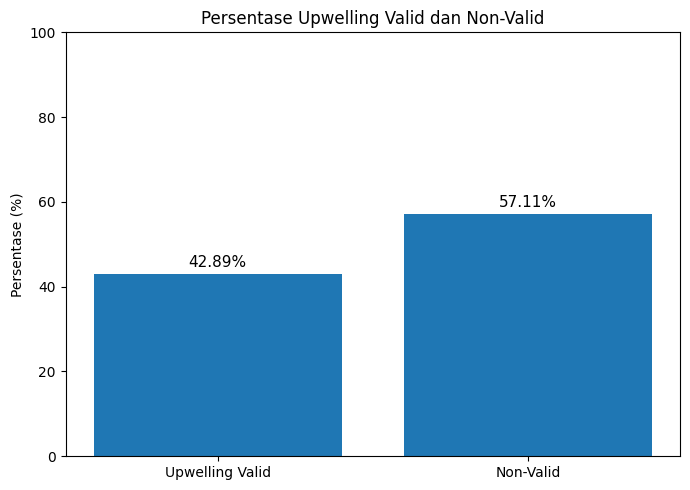

In [26]:
summary_upwelling = plot_upwelling_valid_percentage(
    ds_valid=ds_valid,
    valid_var="upwelling_valid",
    uisst_var="uisst",
    save_path="barplot_upwelling_valid_percentage.png"
)

In [27]:
import numpy as np
import pandas as pd

# ============================================================
# Statistik deskriptif UISST hanya untuk upwelling valid
# Syarat: upwelling_valid == 1
# ============================================================

uisst_var = "uisst"
valid_var = "upwelling_valid"

if uisst_var not in ds_valid.data_vars:
    raise ValueError(f"Variabel '{uisst_var}' tidak ditemukan di ds_valid.")

if valid_var not in ds_valid.data_vars:
    raise ValueError(f"Variabel '{valid_var}' tidak ditemukan di ds_valid.")

# Ambil nilai UISST hanya pada pixel upwelling valid
uisst_valid = ds_valid[uisst_var].where(ds_valid[valid_var] == 1)

# Ubah ke numpy dan buang NaN
uisst_valid_values = uisst_valid.values
uisst_valid_values = uisst_valid_values[np.isfinite(uisst_valid_values)]

if len(uisst_valid_values) == 0:
    raise ValueError("Tidak ada nilai UISST valid dengan upwelling_valid == 1.")

# ============================================================
# Hitung statistik
# ============================================================

uisst_valid_stats = pd.DataFrame({
    "Statistik": ["UISST Valid"],
    "Rata-rata": [np.mean(uisst_valid_values)],
    "Std Deviasi": [np.std(uisst_valid_values, ddof=1)],
    "Minimum": [np.min(uisst_valid_values)],
    "25% (Q1)": [np.percentile(uisst_valid_values, 25)],
    "Median": [np.percentile(uisst_valid_values, 50)],
    "75% (Q3)": [np.percentile(uisst_valid_values, 75)],
    "Maximum": [np.max(uisst_valid_values)],
    "Range": [np.max(uisst_valid_values) - np.min(uisst_valid_values)]
})

display(uisst_valid_stats)

,Statistik,Rata-rata,Std Deviasi,Minimum,25% (Q1),Median,75% (Q3),Maximum,Range
0,UISST Valid,0.567729,0.516439,3.683785e-08,0.184999,0.42,0.799999,6.880001,6.880001


# Intensity Upwelling

In [28]:
ds_valid

<xarray.Dataset> Size: 2GB
Dimensions:          (time: 496, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time             (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat              (lat) float32 2kB 6.979 6.938 6.896 ... -9.938 -9.979
  * lon              (lon) float32 2kB 90.02 90.06 90.1 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    qual_sst         (time, lat, lon) float32 350MB ...
    palette          (time, rgb, eightbitcolor) uint8 381kB ...
    sst              (time, lat, lon) float64 699MB ...
    SST_max          (time, lat) float64 2MB nan nan nan nan ... nan nan nan nan
    SST_max_lon      (lat) float32 2kB nan nan nan nan nan ... nan nan nan nan
    uisst            (time, lat, lon) float64 699MB nan nan nan ... nan nan nan
    upwelling_valid  (time, lat, lon) int8 87MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
Attributes: (12/64)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.SST...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    data_bins:                        99152
    data_minimum:                     24.244999
    data_maximum:                     35.745
    SST_max_processing_note:          SST_max is defined as SSTwest, namely S...
    UISST_processing_note:            uisst was calculated by subtracting all...
    upwelling_valid_processing_note:  upwelling_valid was computed from uisst...

In [29]:
import numpy as np
import xarray as xr


def upwelling_intensity_binning(
    ds_valid,
    mask_2d,
    uisst_var="uisst",
    valid_var="upwelling_valid",
    output_var_name="upwelling_intensity"
):
    """
    Mengklasifikasikan intensitas upwelling berdasarkan mean dan
    standar deviasi UISST positif dari kejadian upwelling valid.

    Data untuk menghitung threshold:
    - inside WPP-NRI 572
    - upwelling_valid == 1
    - UISST > 0
    - UISST bukan NaN

    Rumus:
        Lower Bound = mean(UISST) - 0.5 * std(UISST)
        Upper Bound = mean(UISST) + 0.5 * std(UISST)

    Kelas:
        NaN = di luar WPP-NRI 572
        0   = non-upwelling atau bukan upwelling valid
        1   = weak:
              0 < UISST <= Lower Bound
        2   = intermediate:
              Lower Bound < UISST <= Upper Bound
        3   = strong:
              UISST > Upper Bound
    """

    # ========================================================
    # 1. Validasi input
    # ========================================================
    if uisst_var not in ds_valid.data_vars:
        raise ValueError(
            f"Variabel '{uisst_var}' tidak ditemukan di ds_valid."
        )

    if valid_var not in ds_valid.data_vars:
        raise ValueError(
            f"Variabel '{valid_var}' tidak ditemukan di ds_valid."
        )

    uisst = ds_valid[uisst_var].transpose(
        "time", "lat", "lon"
    )

    upwelling_valid = ds_valid[valid_var].transpose(
        "time", "lat", "lon"
    )

    # ========================================================
    # 2. Menyiapkan mask WPP-NRI 572
    # ========================================================
    if isinstance(mask_2d, xr.DataArray):
        mask_da = (
            mask_2d
            .transpose("lat", "lon")
            .astype(bool)
        )

        try:
            mask_da, _ = xr.align(
                mask_da,
                uisst.isel(time=0, drop=True),
                join="exact"
            )
        except ValueError as exc:
            raise ValueError(
                "Koordinat mask_2d tidak sama dengan "
                "koordinat ds_valid."
            ) from exc

    else:
        mask_array = np.asarray(
            mask_2d,
            dtype=bool
        )

        expected_shape = (
            ds_valid.sizes["lat"],
            ds_valid.sizes["lon"]
        )

        if mask_array.shape != expected_shape:
            raise ValueError(
                f"Shape mask_2d {mask_array.shape} tidak sesuai "
                f"dengan dimensi lat-lon {expected_shape}."
            )

        mask_da = xr.DataArray(
            mask_array,
            coords={
                "lat": ds_valid["lat"],
                "lon": ds_valid["lon"]
            },
            dims=("lat", "lon"),
            name="wpp_mask"
        )

    # ========================================================
    # 3. Ambil UISST positif dari upwelling valid
    # ========================================================
    threshold_domain = (
        mask_da
        & np.isfinite(uisst)
        & (upwelling_valid == 1)
        & (uisst > 0)
    )

    valid_positive_uisst = uisst.where(
        threshold_domain
    )

    threshold_sample_count = int(
        valid_positive_uisst.count().item()
    )

    if threshold_sample_count == 0:
        raise ValueError(
            "Tidak ditemukan UISST > 0 dengan "
            "upwelling_valid == 1."
        )

    # ========================================================
    # 4. Hitung mean, standar deviasi, dan threshold
    # ========================================================
    mean_uisst = float(
        valid_positive_uisst.mean(
            dim=("time", "lat", "lon"),
            skipna=True
        ).item()
    )

    std_uisst = float(
        valid_positive_uisst.std(
            dim=("time", "lat", "lon"),
            skipna=True
        ).item()
    )

    lower_bound = mean_uisst - (0.5 * std_uisst)
    upper_bound = mean_uisst + (0.5 * std_uisst)

    print("Threshold intensitas upwelling")
    print(f"Jumlah UISST valid positif : {threshold_sample_count:,}")
    print(f"Mean UISST                 : {mean_uisst:.6f}")
    print(f"Standar deviasi            : {std_uisst:.6f}")
    print(f"Lower Bound                : {lower_bound:.6f}")
    print(f"Upper Bound                : {upper_bound:.6f}")

    # ========================================================
    # 5. Inisialisasi kelas
    #    Luar WPP = NaN
    #    Inside WPP = 0
    # ========================================================
    intensity = xr.where(
        mask_da,
        0.0,
        np.nan
    )

    # Hanya kejadian valid yang dapat memperoleh kelas 1–3
    classification_domain = (
        mask_da
        & np.isfinite(uisst)
        & (upwelling_valid == 1)
        & (uisst > 0)
    )

    # ========================================================
    # 6. Klasifikasi intensitas
    # ========================================================
    weak_mask = (
        classification_domain
        & (uisst <= lower_bound)
    )

    intermediate_mask = (
        classification_domain
        & (uisst > lower_bound)
        & (uisst <= upper_bound)
    )

    strong_mask = (
        classification_domain
        & (uisst > upper_bound)
    )

    intensity = xr.where(
        weak_mask,
        1.0,
        intensity
    )

    intensity = xr.where(
        intermediate_mask,
        2.0,
        intensity
    )

    intensity = xr.where(
        strong_mask,
        3.0,
        intensity
    )

    intensity = intensity.transpose(
        "time", "lat", "lon"
    )

    # ========================================================
    # 7. Tambahkan hasil ke dataset
    # ========================================================
    ds_intensity = ds_valid.copy()

    ds_intensity[output_var_name] = (
        intensity.astype("float32")
    )

    ds_intensity[output_var_name].attrs = {
        "long_name": (
            "Upwelling intensity class based on mean "
            "and standard deviation of valid positive UISST"
        ),
        "definition": (
            "NaN = outside WPP-NRI 572; "
            "0 = non-upwelling or not valid upwelling; "
            f"1 = weak (0 < {uisst_var} <= {lower_bound}); "
            f"2 = intermediate "
            f"({lower_bound} < {uisst_var} <= {upper_bound}); "
            f"3 = strong ({uisst_var} > {upper_bound})."
        ),
        "threshold_data_definition": (
            f"{uisst_var} > 0 and {valid_var} == 1 "
            "inside WPP-NRI 572"
        ),
        "mean_uisst": mean_uisst,
        "std_uisst": std_uisst,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "threshold_formula": (
            "lower_bound = mean - 0.5 * std; "
            "upper_bound = mean + 0.5 * std"
        ),
        "threshold_sample_count": threshold_sample_count,
        "source_uisst_variable": uisst_var,
        "source_valid_variable": valid_var,
        "class_0": "non_upwelling_or_not_valid",
        "class_1": "weak_upwelling",
        "class_2": "intermediate_upwelling",
        "class_3": "strong_upwelling",
        "missing_value": "NaN indicates outside WPP-NRI 572"
    }

    ds_intensity.attrs[
        "upwelling_intensity_processing_note"
    ] = (
        f"{output_var_name} was classified using valid positive "
        f"UISST values. Mean={mean_uisst:.6f}, "
        f"standard deviation={std_uisst:.6f}, "
        f"lower bound={lower_bound:.6f}, "
        f"upper bound={upper_bound:.6f}."
    )

    return ds_intensity

In [30]:
ds_intensity = upwelling_intensity_binning(
    ds_valid=ds_valid,
    mask_2d=mask_2d,
    uisst_var="uisst",
    valid_var="upwelling_valid",
    output_var_name="upwelling_intensity"
)

Threshold intensitas upwelling
Jumlah UISST valid positif : 9,372,243
Mean UISST                 : 0.567729
Standar deviasi            : 0.516439
Lower Bound                : 0.309509
Upper Bound                : 0.825949


In [31]:
ds_intensity

<xarray.Dataset> Size: 2GB
Dimensions:              (time: 496, lat: 408, lon: 432, rgb: 3,
                          eightbitcolor: 256)
Coordinates:
  * time                 (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat                  (lat) float32 2kB 6.979 6.938 6.896 ... -9.938 -9.979
  * lon                  (lon) float32 2kB 90.02 90.06 90.1 ... 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    qual_sst             (time, lat, lon) float32 350MB ...
    palette              (time, rgb, eightbitcolor) uint8 381kB ...
    sst                  (time, lat, lon) float64 699MB ...
    SST_max              (time, lat) float64 2MB nan nan nan nan ... nan nan nan
    SST_max_lon          (lat) float32 2kB nan nan nan nan ... nan nan nan nan
    uisst                (time, lat, lon) float64 699MB nan nan nan ... nan nan
    upwelling_valid      (time, lat, lon) int8 87MB 0 0 0 0 0 0 ... 0 0 0 0 0 0
    upwelling_intensity  (time, lat, lon) float32 350MB nan nan nan ... nan nan
Attributes: (12/65)
    product_name:                         AQUA_MODIS.20140101_20140108.L3m.8D...
    instrument:                           MODIS
    title:                                MODISA Level-3 Equidistant Cylindri...
    project:                              Ocean Biology Processing Group (NAS...
    platform:                             Aqua
    source:                               satellite observations from MODIS-Aqua
    ...                                   ...
    data_minimum:                         24.244999
    data_maximum:                         35.745
    SST_max_processing_note:              SST_max is defined as SSTwest, name...
    UISST_processing_note:                uisst was calculated by subtracting...
    upwelling_valid_processing_note:      upwelling_valid was computed from u...
    upwelling_intensity_processing_note:  upwelling_intensity was classified ...

In [32]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

def plot_upwelling_intensity_percentage_inside_wpp_fixed(
    ds_intensity,
    mask_2d,
    intensity_var="upwelling_intensity",
    save_path=None
):
    """
    Membuat barplot persentase kelas upwelling_intensity
    dengan denominator hanya area inside WPPNRI 572.

    Kelas:
    0 = non-upwelling
    1 = weak upwelling
    2 = intermediate upwelling
    3 = strong upwelling
    """

    if intensity_var not in ds_intensity.data_vars:
        raise ValueError(f"Variabel '{intensity_var}' tidak ditemukan di ds_intensity.")

    lats = ds_intensity["lat"].values
    lons = ds_intensity["lon"].values

    mask_2d = np.asarray(mask_2d).astype(bool)

    if mask_2d.shape != (len(lats), len(lons)):
        raise ValueError(
            f"Shape mask_2d {mask_2d.shape} tidak sesuai dengan "
            f"dimensi lat-lon ({len(lats)}, {len(lons)})."
        )

    intensity = ds_intensity[intensity_var]

    mask_da = xr.DataArray(
        mask_2d,
        coords={"lat": ds_intensity["lat"], "lon": ds_intensity["lon"]},
        dims=("lat", "lon")
    )

    # Denominator: hanya seluruh pixel-time di dalam WPP
    total_inside_wpp = int(mask_2d.sum() * ds_intensity.sizes["time"])

    class_map = {
        0: "Non-Upwelling",
        1: "Weak Upwelling",
        2: "Intermediate Upwelling",
        3: "Strong Upwelling"
    }

    rows = []

    for kelas, label in class_map.items():
        # Numerator juga harus dibatasi inside WPP
        count = int(((intensity == kelas) & mask_da).sum().values)
        percentage = count / total_inside_wpp * 100

        rows.append({
            "kelas": kelas,
            "label": label,
            "jumlah": count,
            "persentase": percentage
        })

    summary_df = pd.DataFrame(rows)

    # Validasi total
    total_pct = summary_df["persentase"].sum()
    total_count = summary_df["jumlah"].sum()

    print("Total pixel-time inside WPP:", total_inside_wpp)
    print("Total count semua kelas    :", total_count)
    print("Total persentase semua kelas:", total_pct)

    display(summary_df)

    # ========================================================
    # Barplot
    # ========================================================

    fig, ax = plt.subplots(figsize=(9, 5))

    bars = ax.bar(
        summary_df["label"],
        summary_df["persentase"]
    )

    ax.set_title("Persentase Kelas Upwelling Intensity di Inside WPPNRI 572")
    ax.set_xlabel("Kelas Upwelling Intensity")
    ax.set_ylabel("Persentase (%)")
    ax.set_ylim(0, 100)

    for bar, pct in zip(bars, summary_df["persentase"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{pct:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.xticks(rotation=15)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot disimpan ke: {save_path}")

    plt.show()

    return summary_df

Total pixel-time inside WPP: 21850784
Total count semua kelas    : 21850784
Total persentase semua kelas: 100.0


,kelas,label,jumlah,persentase
0,0,Non-Upwelling,12478541,57.107978
1,1,Weak Upwelling,3666571,16.780043
2,2,Intermediate Upwelling,3484256,15.945680
3,3,Strong Upwelling,2221416,10.166299


Plot disimpan ke: barplot_upwelling_intensity_inside_wpp.png


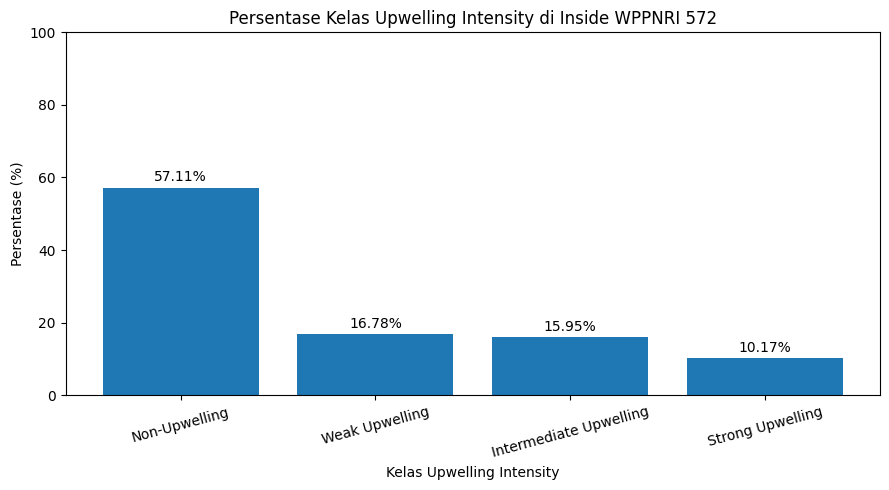

In [33]:
summary_intensity = plot_upwelling_intensity_percentage_inside_wpp_fixed(
    ds_intensity=ds_intensity,
    mask_2d=mask_2d,
    intensity_var="upwelling_intensity",
    save_path="barplot_upwelling_intensity_inside_wpp.png"
)

# PLOT ANALISIS

In [34]:
ds_chl1 = xr.open_dataset('/kaggle/input/notebooks/andreh19/3-1-3d-dineof/ds_wpp_3d_clean.nc')
ds_chl = ds_chl1.drop_vars("chlor_a")
ds_chl = ds_chl.rename({"chlor_a_3ddineof": "chlor_a"})
ds_chl

<xarray.Dataset> Size: 712MB
Dimensions:  (time: 505, rgb: 3, eightbitcolor: 256, lat: 408, lon: 432)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    palette  (time, rgb, eightbitcolor) uint8 388kB ...
    chlor_a  (time, lat, lon) float64 712MB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

In [35]:
def winsorized_var(ds, var, persentil=99.5):
    if var not in ds.data_vars:
        raise ValueError(f"Variabel '{var}' tidak ditemukan di dataset.")

    # Ambil DataArray asli
    da = ds[var]

    # Copy data ke numpy array
    data = da.values.copy()

    # Mask data valid
    valid_mask = np.isfinite(data)

    if valid_mask.sum() == 0:
        raise ValueError(f"Tidak ada data valid pada variabel '{var}'.")

    # Total data
    total_data_semua = data.size
    total_data_valid = int(valid_mask.sum())

    # Hitung persentil dari data valid
    batas_persentil = np.nanpercentile(data[valid_mask], persentil)

    # Hitung jumlah data yang lebih besar dari batas persentil
    outlier_mask = valid_mask & (data > batas_persentil)
    n_outlier = int(outlier_mask.sum())

    # Persentase outlier
    persen_dari_semua_data = (n_outlier / total_data_semua) * 100
    persen_dari_data_valid = (n_outlier / total_data_valid) * 100

    # Statistik sebelum winsorized
    max_before = float(np.nanmax(data[valid_mask]))
    min_before = float(np.nanmin(data[valid_mask]))
    mean_before = float(np.nanmean(data[valid_mask]))
    std_before = float(np.nanstd(data[valid_mask]))

    # Lakukan winsorized
    data[outlier_mask] = batas_persentil

    # Statistik sesudah winsorized
    valid_after = np.isfinite(data)
    max_after = float(np.nanmax(data[valid_after]))
    min_after = float(np.nanmin(data[valid_after]))
    mean_after = float(np.nanmean(data[valid_after]))
    std_after = float(np.nanstd(data[valid_after]))

    # Ganti langsung nilai pada variabel yang sama
    attrs_lama = da.attrs.copy()

    ds[var] = xr.DataArray(
        data,
        dims=da.dims,
        coords=da.coords,
        attrs=attrs_lama,
        name=var
    )

    ds[var].attrs["winsorized"] = "True"
    ds[var].attrs["winsorized_percentile"] = persentil
    ds[var].attrs["winsorized_upper_value"] = float(batas_persentil)
    ds[var].attrs["n_values_above_percentile_replaced"] = n_outlier
    ds[var].attrs["percentage_above_percentile_from_all_data"] = float(persen_dari_semua_data)
    ds[var].attrs["percentage_above_percentile_from_valid_data"] = float(persen_dari_data_valid)

    print("=== WINSORIZED SELESAI ===")
    print(f"Variabel                          : {var}")
    print(f"Persentil                         : P{persentil}")
    print(f"Nilai batas persentil             : {batas_persentil}")
    print("")
    print(f"Total seluruh data                : {total_data_semua}")
    print(f"Total data valid                  : {total_data_valid}")
    print(f"Jumlah data diatas persentil      : {n_outlier}")
    print(f"Persentase dari seluruh data      : {persen_dari_semua_data:.6f}%")
    print(f"Persentase dari data valid        : {persen_dari_data_valid:.6f}%")
    print("")
    print("Sebelum winsorized:")
    print(f"  Minimum                         : {min_before}")
    print(f"  Maximum                         : {max_before}")
    print(f"  Mean                            : {mean_before}")
    print(f"  Std                             : {std_before}")
    print("")
    print("Sesudah winsorized:")
    print(f"  Minimum                         : {min_after}")
    print(f"  Maximum                         : {max_after}")
    print(f"  Mean                            : {mean_after}")
    print(f"  Std                             : {std_after}")

    return ds

In [36]:
ds_chl_clean = winsorized_var(
    ds=ds_chl,
    var="chlor_a",
    persentil=99.5
)

=== WINSORIZED SELESAI ===
Variabel                          : chlor_a
Persentil                         : P99.5
Nilai batas persentil             : 2.8669129526615436

Total seluruh data                : 89009280
Total data valid                  : 22247270
Jumlah data diatas persentil      : 111237
Persentase dari seluruh data      : 0.124972%
Persentase dari data valid        : 0.500003%

Sebelum winsorized:
  Minimum                         : 1.998536491984959e-05
  Maximum                         : 1212.8475976762763
  Mean                            : 0.21444409445063026
  Std                             : 0.6775673790689369

Sesudah winsorized:
  Minimum                         : 1.998536491984959e-05
  Maximum                         : 2.8669129526615436
  Mean                            : 0.1990759647453314
  Std                             : 0.3076487759628932


In [37]:
ds_chl_clean

<xarray.Dataset> Size: 712MB
Dimensions:  (time: 505, rgb: 3, eightbitcolor: 256, lat: 408, lon: 432)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    palette  (time, rgb, eightbitcolor) uint8 388kB ...
    chlor_a  (time, lat, lon) float64 712MB nan nan nan nan ... nan nan nan nan
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

In [38]:
ds_chl_clean['chlor_a']

<xarray.DataArray 'chlor_a' (time: 505, lat: 408, lon: 432)> Size: 712MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(505, 408, 432))
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Attributes: (12/32)
    long_name:                                    Chlorophyll Concentration, ...
    units:                                        mg m^-3
    standard_name:                                mass_concentration_of_chlor...
    valid_min:                                    0.001
    valid_max:                                    100.0
    reference:                                    Hu, C., Lee Z., and Franz, ...
    ...                                           ...
    winsorized:                                   True
    winsorized_percentile:                        99.5
    winsorized_upper_value:                       2.8669129526615436
    n_values_above_percentile_replaced:           111237
    percentage_above_percentile_from_all_data:    0.12497236243232167
    percentage_above_percentile_from_valid_data:  0.5000029217067982

## Analisis Setiap Kelas

In [39]:
import numpy as np
import pandas as pd
import xarray as xr

def intensity_sst_chl_statistics(
    ds_intensity,
    ds_chl_clean,
    mask_2d,
    intensity_var="upwelling_intensity",
    sst_var="sst",
    chl_var="chlor_a",
    treat_nan_inside_wpp_as_class0=True,
    round_digits=4
):
    """
    Membuat tabel statistik SST dan chlor-a untuk setiap kelas upwelling intensity.

    Output:
    kelas | label | Min SST | Mean SST | Max SST | Min CHL | Mean CHL | Max CHL | jumlah_pixel_time

    Kelas:
    0 = non-upwelling
    1 = weak upwelling
    2 = intermediate upwelling
    3 = strong upwelling
    """

    # ========================================================
    # 1. Validasi variabel
    # ========================================================

    if intensity_var not in ds_intensity.data_vars:
        raise ValueError(f"Variabel '{intensity_var}' tidak ditemukan di ds_intensity.")

    if sst_var not in ds_intensity.data_vars:
        raise ValueError(f"Variabel '{sst_var}' tidak ditemukan di ds_intensity.")

    if chl_var not in ds_chl_clean.data_vars:
        raise ValueError(f"Variabel '{chl_var}' tidak ditemukan di ds_chl_clean.")

    # ========================================================
    # 2. Ambil common time berdasarkan ds_intensity
    # ========================================================

    common_time = np.intersect1d(
        ds_intensity["time"].values,
        ds_chl_clean["time"].values
    )

    if len(common_time) == 0:
        raise ValueError("Tidak ada timestamp yang sama antara ds_intensity dan ds_chl_clean.")

    ds_i = ds_intensity.sel(time=common_time)
    ds_c = ds_chl_clean.sel(time=common_time)

    # ========================================================
    # 3. Samakan urutan dimensi menjadi time-lat-lon
    # ========================================================

    sst = ds_i[sst_var].transpose("time", "lat", "lon")
    chl = ds_c[chl_var].transpose("time", "lat", "lon")
    intensity = ds_i[intensity_var].transpose("time", "lat", "lon")

    lats = ds_i["lat"].values
    lons = ds_i["lon"].values

    mask_2d = np.asarray(mask_2d).astype(bool)

    if mask_2d.shape != (len(lats), len(lons)):
        raise ValueError(
            f"Shape mask_2d {mask_2d.shape} tidak sesuai dengan "
            f"dimensi lat-lon ({len(lats)}, {len(lons)})."
        )

    mask_da = xr.DataArray(
        mask_2d,
        coords={"lat": ds_i["lat"], "lon": ds_i["lon"]},
        dims=("lat", "lon")
    )

    # ========================================================
    # 4. Pastikan hanya inside WPP yang dianalisis
    # ========================================================

    sst = sst.where(mask_da)
    chl = chl.where(mask_da)
    intensity = intensity.where(mask_da)

    # Jika masih ada NaN di inside WPP dan ingin dianggap kelas 0
    if treat_nan_inside_wpp_as_class0:
        intensity = xr.where(mask_da & intensity.isnull(), 0, intensity)

    # ========================================================
    # 5. Hitung statistik per kelas
    # ========================================================

    class_map = {
        0: "Non-Upwelling",
        1: "Weak Upwelling",
        2: "Intermediate Upwelling",
        3: "Strong Upwelling"
    }

    rows = []

    for kelas, label in class_map.items():

        class_mask = (intensity == kelas) & mask_da

        sst_class = sst.where(class_mask)
        chl_class = chl.where(class_mask)

        sst_values = sst_class.values
        chl_values = chl_class.values

        sst_values = sst_values[np.isfinite(sst_values)]
        chl_values = chl_values[np.isfinite(chl_values)]

        n_pixel_time = int(class_mask.sum().values)

        row = {
            "kelas": kelas,
            "label": label,
            "jumlah_pixel_time": n_pixel_time,

            "Nilai Min SST": np.nan if len(sst_values) == 0 else np.min(sst_values),
            "Mean SST": np.nan if len(sst_values) == 0 else np.mean(sst_values),
            "Nilai Max SST": np.nan if len(sst_values) == 0 else np.max(sst_values),

            "Min CHL": np.nan if len(chl_values) == 0 else np.min(chl_values),
            "Mean CHL": np.nan if len(chl_values) == 0 else np.mean(chl_values),
            "Max CHL": np.nan if len(chl_values) == 0 else np.max(chl_values),
        }

        rows.append(row)

    stats_df = pd.DataFrame(rows)

    # ========================================================
    # 6. Pembulatan
    # ========================================================

    numeric_cols = [
        "Nilai Min SST",
        "Mean SST",
        "Nilai Max SST",
        "Min CHL",
        "Mean CHL",
        "Max CHL"
    ]

    stats_df[numeric_cols] = stats_df[numeric_cols].round(round_digits)

    # ========================================================
    # 7. Tambahkan informasi persentase kelas
    # ========================================================

    total_inside_wpp_pixel_time = int(mask_2d.sum() * len(common_time))

    stats_df["persentase_inside_wpp"] = (
        stats_df["jumlah_pixel_time"] / total_inside_wpp_pixel_time * 100
    ).round(4)

    print("Jumlah timestamp ds_intensity:", ds_intensity.sizes["time"])
    print("Jumlah timestamp ds_chl_clean :", ds_chl_clean.sizes["time"])
    print("Jumlah common timestamp dipakai:", len(common_time))
    print("Total pixel-time inside WPP:", total_inside_wpp_pixel_time)

    display(stats_df)

    return stats_df

In [40]:
stats_intensity_sst_chl = intensity_sst_chl_statistics(
    ds_intensity=ds_intensity,
    ds_chl_clean=ds_chl_clean,
    mask_2d=mask_2d,
    intensity_var="upwelling_intensity",
    sst_var="sst",
    chl_var="chlor_a",
    treat_nan_inside_wpp_as_class0=True,
    round_digits=4
)

Jumlah timestamp ds_intensity: 496
Jumlah timestamp ds_chl_clean : 505
Jumlah common timestamp dipakai: 496
Total pixel-time inside WPP: 21850784


,kelas,label,jumlah_pixel_time,Nilai Min SST,Mean SST,Nilai Max SST,Min CHL,Mean CHL,Max CHL,persentase_inside_wpp
0,0,Non-Upwelling,12478541,24.055,30.1665,37.445,0.0000,0.2003,2.8669,57.1080
1,1,Weak Upwelling,3666571,24.155,29.5004,34.840,0.0010,0.1696,2.8669,16.7800
2,2,Intermediate Upwelling,3484256,23.785,29.2911,34.585,0.0007,0.1930,2.8669,15.9457
3,3,Strong Upwelling,2221416,19.525,28.9807,33.245,0.0003,0.2516,2.8669,10.1663


In [41]:
stats_intensity_sst_chl.to_csv(
    "statistik_sst_chl_per_kelas_upwelling_intensity.csv",
    index=False
)

## Upwelling Valid All Time

In [42]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


def plot_upwelling_valid_all_time(
    ds_intensity,
    upwelling_var="upwelling_valid",
    mask_2d=None,
    intensity_var="upwelling_intensity",
    save_path=None,
    figsize=(10, 8),
    cmap="YlGnBu"
):
    """
    Plot peta jumlah kejadian upwelling valid sepanjang waktu.

    Parameter
    ---------
    ds_intensity : xarray.Dataset
        Dataset yang memiliki variabel upwelling_valid.

    upwelling_var : str
        Nama variabel upwelling valid dengan nilai 0/1.

    mask_2d : numpy.ndarray, xarray.DataArray, atau None
        Mask wilayah WPP dengan dimensi (lat, lon).

    intensity_var : str
        Variabel yang digunakan untuk membentuk mask jika
        mask_2d tidak diberikan.

    save_path : str atau None
        Lokasi penyimpanan gambar.

    figsize : tuple
        Ukuran figure.

    cmap : str
        Colormap untuk visualisasi. Default: viridis.

    Returns
    -------
    upwelling_sum : xarray.DataArray
        Jumlah kejadian upwelling valid pada setiap piksel.
    """

    # ========================================================
    # 1. Validasi variabel
    # ========================================================
    if upwelling_var not in ds_intensity.data_vars:
        raise ValueError(
            f"Variabel '{upwelling_var}' tidak ditemukan "
            "di ds_intensity."
        )

    upwelling_valid = ds_intensity[upwelling_var].transpose(
        "time",
        "lat",
        "lon"
    )

    lats = ds_intensity["lat"].values
    lons = ds_intensity["lon"].values

    # ========================================================
    # 2. Tentukan mask inside WPP
    # ========================================================
    if mask_2d is not None:

        if isinstance(mask_2d, xr.DataArray):
            inside_wpp_da = (
                mask_2d
                .transpose("lat", "lon")
                .astype(bool)
            )

            inside_wpp_da, _ = xr.align(
                inside_wpp_da,
                upwelling_valid.isel(time=0, drop=True),
                join="exact"
            )

        else:
            mask_array = np.asarray(
                mask_2d,
                dtype=bool
            )

            expected_shape = (
                len(lats),
                len(lons)
            )

            if mask_array.shape != expected_shape:
                raise ValueError(
                    f"Shape mask_2d {mask_array.shape} tidak "
                    f"sesuai dengan dimensi lat-lon "
                    f"{expected_shape}."
                )

            inside_wpp_da = xr.DataArray(
                mask_array,
                coords={
                    "lat": ds_intensity["lat"],
                    "lon": ds_intensity["lon"]
                },
                dims=("lat", "lon")
            )

    else:
        if intensity_var not in ds_intensity.data_vars:
            raise ValueError(
                f"mask_2d tidak diberikan dan variabel "
                f"'{intensity_var}' tidak ditemukan."
            )

        intensity = ds_intensity[intensity_var].transpose(
            "time",
            "lat",
            "lon"
        )

        inside_wpp_da = np.isfinite(
            intensity
        ).any(dim="time")

    # ========================================================
    # 3. Hitung jumlah kejadian upwelling valid
    # ========================================================
    upwelling_sum = (
        (upwelling_valid == 1)
        .sum(dim="time")
        .where(inside_wpp_da)
        .rename("upwelling_valid_count")
    )

    # Nilai nol tidak diberi warna
    upwelling_plot = upwelling_sum.where(
        upwelling_sum > 0
    )

    # ========================================================
    # 4. Plot
    # ========================================================
    lon2d, lat2d = np.meshgrid(
        lons,
        lats
    )

    fig, ax = plt.subplots(
        figsize=figsize
    )

    mesh = ax.pcolormesh(
        lon2d,
        lat2d,
        upwelling_plot.values,
        shading="auto",
        cmap=cmap
    )

    # Outline WPP-NRI 572
    ax.contour(
        lon2d,
        lat2d,
        inside_wpp_da.values.astype(int),
        levels=[0.5],
        colors="black",
        linewidths=0.8
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.02
    )

    cbar.set_label(
        "Jumlah kejadian upwelling valid"
    )

    ax.set_title(
        "Distribusi Kejadian Upwelling Valid 2014–2024"
    )

    ax.set_xlabel(
        "Longitude [degrees_east]"
    )

    ax.set_ylabel(
        "Latitude [degrees_north]"
    )

    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.5
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            f"Plot disimpan ke: {save_path}"
        )

    plt.show()

    return upwelling_sum

Plot disimpan ke: map_upwelling_valid_all_time.png


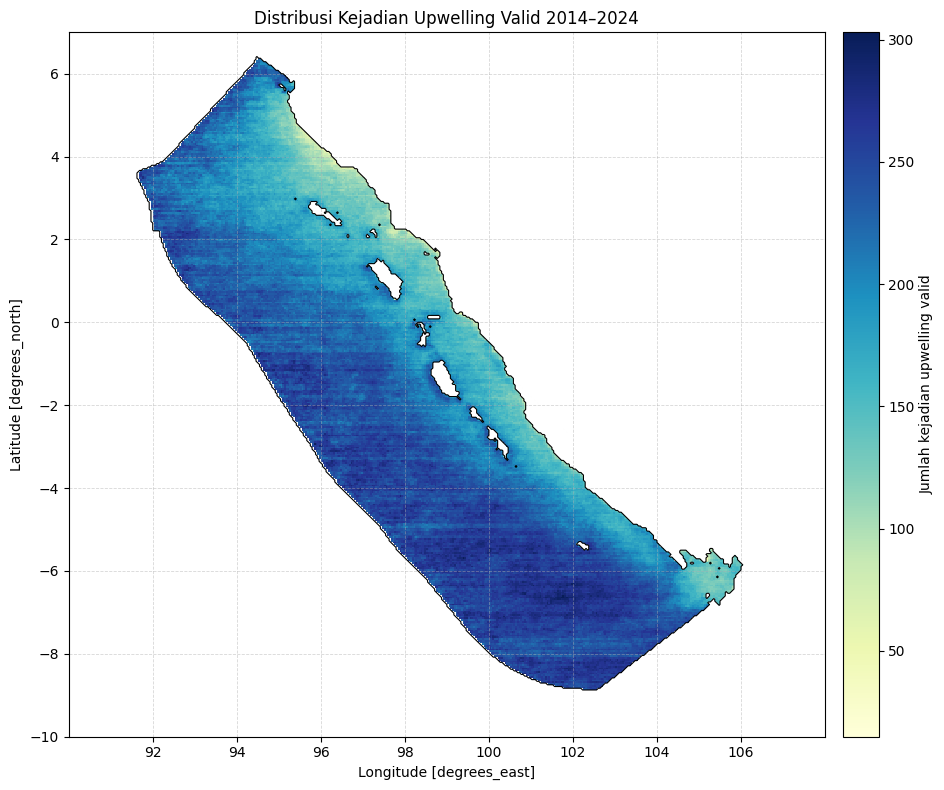

In [43]:
upwelling_sum = plot_upwelling_valid_all_time(
    ds_intensity=ds_intensity,
    upwelling_var="upwelling_valid",
    mask_2d=mask_2d,
    intensity_var="upwelling_intensity",
    save_path="map_upwelling_valid_all_time.png",
    figsize=(10, 8)
)

## Upwelling Valid (annualy dan monthly)

In [44]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

def plot_upwelling_valid_monthly_yearly_revised(
    ds_intensity,
    mask_2d,
    upwelling_var="upwelling_valid",
    start_date=None,
    end_date="2024-12-31",
    save_path=None,
    figsize=(12, 9)
):
    """
    Menampilkan 2 plot dalam 1 figure:
    1. Count upwelling valid per bulan
    2. Count upwelling valid per tahun

    Catatan:
    - Data dibatasi sampai end_date, default 2024-12-31.
    - Tahun 2025 tidak ikut dihitung.
    - Count dihitung dari jumlah nilai upwelling_valid == 1
      pada area inside WPPNRI 572.
    """

    # ========================================================
    # 1. Validasi input
    # ========================================================

    if upwelling_var not in ds_intensity.data_vars:
        raise ValueError(f"Variabel '{upwelling_var}' tidak ditemukan di ds_intensity.")

    lats = ds_intensity["lat"].values
    lons = ds_intensity["lon"].values

    mask_2d = np.asarray(mask_2d).astype(bool)

    if mask_2d.shape != (len(lats), len(lons)):
        raise ValueError(
            f"Shape mask_2d {mask_2d.shape} tidak sesuai dengan "
            f"dimensi lat-lon ({len(lats)}, {len(lons)})."
        )

    # ========================================================
    # 2. Filter waktu sampai Desember 2024
    # ========================================================

    if start_date is not None:
        ds_plot = ds_intensity.sel(time=slice(start_date, end_date))
    else:
        ds_plot = ds_intensity.sel(time=slice(None, end_date))

    # Pastikan 2025 benar-benar tidak ikut
    ds_plot = ds_plot.where(ds_plot["time"].dt.year <= 2024, drop=True)

    if ds_plot.sizes["time"] == 0:
        raise ValueError("Tidak ada timestamp setelah filter waktu.")

    upwelling_valid = ds_plot[upwelling_var].transpose("time", "lat", "lon")
    times = pd.to_datetime(ds_plot["time"].values)

    # ========================================================
    # 3. Mask inside WPP
    # ========================================================

    mask_da = xr.DataArray(
        mask_2d,
        coords={"lat": ds_plot["lat"], "lon": ds_plot["lon"]},
        dims=("lat", "lon")
    )

    # Hanya inside WPP dan hanya nilai upwelling_valid == 1
    upwelling_inside_wpp = (upwelling_valid == 1) & mask_da

    # Count upwelling valid per timestamp
    count_per_time = (
        upwelling_inside_wpp
        .sum(dim=("lat", "lon"))
        .values
    )

    time_df = pd.DataFrame({
        "time": times,
        "count_upwelling_valid": count_per_time
    })

    time_df["year"] = time_df["time"].dt.year
    time_df["month"] = time_df["time"].dt.month

    # ========================================================
    # 4. Akumulasi count per bulan dan per tahun
    # ========================================================

    monthly_summary = (
        time_df
        .groupby("month", as_index=False)
        .agg(
            count_upwelling_valid=("count_upwelling_valid", "sum"),
            n_timestamp=("time", "count")
        )
    )

    yearly_summary = (
        time_df
        .groupby("year", as_index=False)
        .agg(
            count_upwelling_valid=("count_upwelling_valid", "sum"),
            n_timestamp=("time", "count")
        )
    )

    month_labels = {
        1: "Jan",
        2: "Feb",
        3: "Mar",
        4: "Apr",
        5: "Mei",
        6: "Jun",
        7: "Jul",
        8: "Agu",
        9: "Sep",
        10: "Okt",
        11: "Nov",
        12: "Des"
    }

    monthly_summary["month_label"] = monthly_summary["month"].map(month_labels)

    # Supaya semua bulan tetap muncul walaupun ada bulan yang tidak punya data
    all_months = pd.DataFrame({
        "month": list(range(1, 13)),
        "month_label": [month_labels[i] for i in range(1, 13)]
    })

    monthly_summary = all_months.merge(
        monthly_summary,
        on=["month", "month_label"],
        how="left"
    )

    monthly_summary["count_upwelling_valid"] = monthly_summary["count_upwelling_valid"].fillna(0)
    monthly_summary["n_timestamp"] = monthly_summary["n_timestamp"].fillna(0).astype(int)

    # ========================================================
    # 5. Plot 2 row, 1 col
    # ========================================================

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize
    )

    # Plot 1: Bulanan
    axes[0].bar(
        monthly_summary["month_label"],
        monthly_summary["count_upwelling_valid"]
    )

    axes[0].set_title("Upwelling Valid per Bulan")
    axes[0].set_xlabel("Bulan")
    axes[0].set_ylabel("Count upwelling valid")
    axes[0].grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.5
    )

    for i, value in enumerate(monthly_summary["count_upwelling_valid"]):
        axes[0].text(
            i,
            value,
            f"{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # Plot 2: Tahunan
    axes[1].bar(
        yearly_summary["year"].astype(str),
        yearly_summary["count_upwelling_valid"]
    )

    axes[1].set_title("Upwelling Valid per Tahun")
    axes[1].set_xlabel("Tahun")
    axes[1].set_ylabel("Count upwelling valid")
    axes[1].grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.5
    )

    for i, value in enumerate(yearly_summary["count_upwelling_valid"]):
        axes[1].text(
            i,
            value,
            f"{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    fig.suptitle(
        f"Upwelling Valid",
        fontsize=13,
        y=1.02
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot disimpan ke: {save_path}")

    plt.show()

    return monthly_summary, yearly_summary, time_df

Plot disimpan ke: count_upwelling_valid_monthly_yearly_until_2024.png


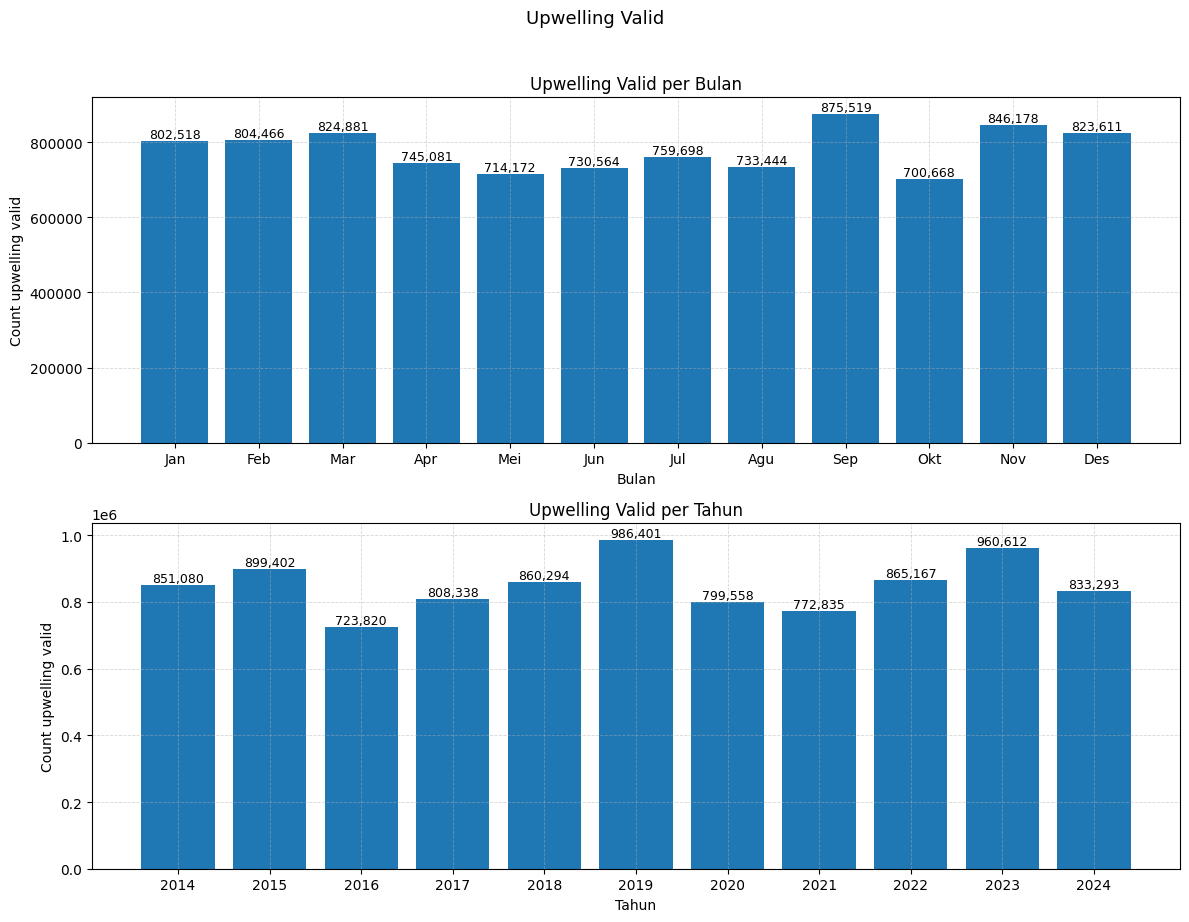

In [45]:
monthly_upwelling_rev, yearly_upwelling_rev, time_upwelling_rev = plot_upwelling_valid_monthly_yearly_revised(
    ds_intensity=ds_intensity,
    mask_2d=mask_2d,
    upwelling_var="upwelling_valid",
    end_date="2024-12-31",
    save_path="count_upwelling_valid_monthly_yearly_until_2024.png",
    figsize=(12, 9)
)

## Barplot Intensitas Upwelling (annualy dan monthly)

In [46]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

def plot_upwelling_intensity_grouped_monthly_yearly_3class(
    ds_intensity,
    mask_2d,
    intensity_var="upwelling_intensity",
    end_date="2024-12-31",
    value_mode="count",          # "count" atau "percentage"
    percentage_base="upwelling", # "upwelling" atau "inside_wpp"
    show_values=False,
    save_path=None,
    figsize=(15, 10)
):
    """
    Membuat 2 grouped barplot dalam 1 figure:
    1. Barplot intensitas upwelling per bulan
    2. Barplot intensitas upwelling per tahun

    Hanya menggunakan 3 kelas:
    1 = Weak Upwelling
    2 = Intermediate Upwelling
    3 = Strong Upwelling

    Kelas 0 atau non-upwelling tidak ditampilkan.
    Data hanya dihitung sampai Desember 2024.
    """

    # ========================================================
    # 1. Validasi input
    # ========================================================

    if intensity_var not in ds_intensity.data_vars:
        raise ValueError(f"Variabel '{intensity_var}' tidak ditemukan di ds_intensity.")

    if value_mode not in ["count", "percentage"]:
        raise ValueError("value_mode harus 'count' atau 'percentage'.")

    if percentage_base not in ["upwelling", "inside_wpp"]:
        raise ValueError("percentage_base harus 'upwelling' atau 'inside_wpp'.")

    # ========================================================
    # 2. Filter waktu sampai 2024
    # ========================================================

    ds_plot = ds_intensity.sel(time=slice(None, end_date))
    ds_plot = ds_plot.where(ds_plot["time"].dt.year <= 2024, drop=True)

    if ds_plot.sizes["time"] == 0:
        raise ValueError("Tidak ada data setelah filter waktu sampai 2024.")

    lats = ds_plot["lat"].values
    lons = ds_plot["lon"].values
    times = pd.to_datetime(ds_plot["time"].values)

    mask_2d = np.asarray(mask_2d).astype(bool)

    if mask_2d.shape != (len(lats), len(lons)):
        raise ValueError(
            f"Shape mask_2d {mask_2d.shape} tidak sesuai dengan "
            f"dimensi lat-lon ({len(lats)}, {len(lons)})."
        )

    mask_da = xr.DataArray(
        mask_2d,
        coords={"lat": ds_plot["lat"], "lon": ds_plot["lon"]},
        dims=("lat", "lon")
    )

    n_grid_inside_wpp = int(mask_2d.sum())

    # ========================================================
    # 3. Ambil intensity dan batasi inside WPP
    # ========================================================

    intensity = ds_plot[intensity_var].transpose("time", "lat", "lon")
    intensity_inside = intensity.where(mask_da)

    # ========================================================
    # 4. Informasi waktu
    # ========================================================

    time_df = pd.DataFrame({
        "time": times
    })

    time_df["year"] = time_df["time"].dt.year
    time_df["month"] = time_df["time"].dt.month

    month_labels = {
        1: "Jan",
        2: "Feb",
        3: "Mar",
        4: "Apr",
        5: "Mei",
        6: "Jun",
        7: "Jul",
        8: "Agu",
        9: "Sep",
        10: "Okt",
        11: "Nov",
        12: "Des"
    }

    class_order = [1, 2, 3]

    class_labels = {
        1: "Weak",
        2: "Intermediate",
        3: "Strong"
    }
    
    class_colors = {
        1: "tab:blue",   # Warna untuk Weak
        2: "tab:orange", # Warna untuk Intermediate
        3: "red"         # Warna untuk Strong menjadi MERAH
    }

    # ========================================================
    # 5. Summary monthly
    # ========================================================

    monthly_summary = pd.DataFrame({
        "month": list(range(1, 13)),
        "month_label": [month_labels[i] for i in range(1, 13)]
    })

    monthly_n_timestamp = time_df.groupby("month").size()

    monthly_summary["n_timestamp"] = (
        monthly_summary["month"]
        .map(monthly_n_timestamp)
        .fillna(0)
        .astype(int)
    )

    for kelas in class_order:
        class_event = (intensity_inside == kelas) & mask_da

        monthly_count_da = (
            class_event
            .groupby("time.month")
            .sum(dim=("time", "lat", "lon"))
        )

        monthly_count_series = monthly_count_da.to_series()

        monthly_summary[f"class_{kelas}_count"] = (
            monthly_summary["month"]
            .map(monthly_count_series)
            .fillna(0)
            .astype(int)
        )

    monthly_summary["total_upwelling_count"] = (
        monthly_summary["class_1_count"]
        + monthly_summary["class_2_count"]
        + monthly_summary["class_3_count"]
    )

    monthly_summary["possible_event_inside_wpp"] = (
        monthly_summary["n_timestamp"] * n_grid_inside_wpp
    )

    for kelas in class_order:
        if percentage_base == "upwelling":
            denominator = monthly_summary["total_upwelling_count"]
        else:
            denominator = monthly_summary["possible_event_inside_wpp"]

        monthly_summary[f"class_{kelas}_percentage"] = np.where(
            denominator > 0,
            monthly_summary[f"class_{kelas}_count"] / denominator * 100,
            0
        )

    # ========================================================
    # 6. Summary yearly
    # ========================================================

    years = sorted(time_df["year"].unique())

    yearly_summary = pd.DataFrame({
        "year": years
    })

    yearly_n_timestamp = time_df.groupby("year").size()

    yearly_summary["n_timestamp"] = (
        yearly_summary["year"]
        .map(yearly_n_timestamp)
        .fillna(0)
        .astype(int)
    )

    for kelas in class_order:
        class_event = (intensity_inside == kelas) & mask_da

        yearly_count_da = (
            class_event
            .groupby("time.year")
            .sum(dim=("time", "lat", "lon"))
        )

        yearly_count_series = yearly_count_da.to_series()

        yearly_summary[f"class_{kelas}_count"] = (
            yearly_summary["year"]
            .map(yearly_count_series)
            .fillna(0)
            .astype(int)
        )

    yearly_summary["total_upwelling_count"] = (
        yearly_summary["class_1_count"]
        + yearly_summary["class_2_count"]
        + yearly_summary["class_3_count"]
    )

    yearly_summary["possible_event_inside_wpp"] = (
        yearly_summary["n_timestamp"] * n_grid_inside_wpp
    )

    for kelas in class_order:
        if percentage_base == "upwelling":
            denominator = yearly_summary["total_upwelling_count"]
        else:
            denominator = yearly_summary["possible_event_inside_wpp"]

        yearly_summary[f"class_{kelas}_percentage"] = np.where(
            denominator > 0,
            yearly_summary[f"class_{kelas}_count"] / denominator * 100,
            0
        )

    # ========================================================
    # 7. Pilih mode plot
    # ========================================================

    if value_mode == "count":
        suffix = "count"
        ylabel = "Count kejadian intensitas upwelling"
        title_suffix = "Count"
        value_formatter = lambda x: f"{int(x):,}"
    else:
        suffix = "percentage"
        ylabel = "Persentase intensitas upwelling (%)"

        if percentage_base == "upwelling":
            title_suffix = "Persentase terhadap Total Upwelling"
        else:
            title_suffix = "Persentase terhadap Inside WPP"

        value_formatter = lambda x: f"{x:.2f}%"

    # ========================================================
    # 8. Plot grouped barplot
    # ========================================================

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize
    )

    bar_width = 0.23
    offsets = np.array([-1, 0, 1]) * bar_width

    # -------------------------------
    # Plot 1: Monthly
    # -------------------------------

    x_month = np.arange(len(monthly_summary))

    for i, kelas in enumerate(class_order):
        y = monthly_summary[f"class_{kelas}_{suffix}"]

        axes[0].bar(
            x_month + offsets[i],
            y,
            width=bar_width,
            label=class_labels[kelas],
            color=class_colors[kelas]
        )

        if show_values:
            for x_pos, value in zip(x_month + offsets[i], y):
                axes[0].text(
                    x_pos,
                    value,
                    value_formatter(value),
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    rotation=90
                )

    axes[0].set_title(f"{title_suffix} Intensitas Upwelling per Bulan")
    axes[0].set_xlabel("Bulan")
    axes[0].set_ylabel(ylabel)
    axes[0].set_xticks(x_month)
    axes[0].set_xticklabels(monthly_summary["month_label"])
    axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    axes[0].legend(title="Kelas", loc="upper right")

    if value_mode == "percentage":
        axes[0].set_ylim(0, 100)

    # -------------------------------
    # Plot 2: Yearly
    # -------------------------------

    x_year = np.arange(len(yearly_summary))

    for i, kelas in enumerate(class_order):
        y = yearly_summary[f"class_{kelas}_{suffix}"]

        axes[1].bar(
            x_year + offsets[i],
            y,
            width=bar_width,
            label=class_labels[kelas],
            color=class_colors[kelas]
        )

        if show_values:
            for x_pos, value in zip(x_year + offsets[i], y):
                axes[1].text(
                    x_pos,
                    value,
                    value_formatter(value),
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    rotation=90
                )

    axes[1].set_title(f"{title_suffix} Intensitas Upwelling per Tahun")
    axes[1].set_xlabel("Tahun")
    axes[1].set_ylabel(ylabel)
    axes[1].set_xticks(x_year)
    axes[1].set_xticklabels(yearly_summary["year"].astype(str))
    axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    axes[1].legend(title="Kelas", loc="upper right")

    if value_mode == "percentage":
        axes[1].set_ylim(0, 100)

    fig.suptitle(
        "Grouped Barplot Intensitas Upwelling 3 Kelas | Periode sampai 2024",
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot disimpan ke: {save_path}")

    plt.show()

    # ========================================================
    # 9. Informasi pengecekan
    # ========================================================

    print("Jumlah grid inside WPP:", n_grid_inside_wpp)
    print("Jumlah timestamp digunakan:", ds_plot.sizes["time"])
    print("Tanggal awal:", str(times.min().date()))
    print("Tanggal akhir:", str(times.max().date()))
    print("Tahun yang dihitung:", years)
    print("Kelas yang ditampilkan:", class_order)

    return monthly_summary, yearly_summary

Plot disimpan ke: barplot_intensitas_upwelling_3class_count_until_2024.png


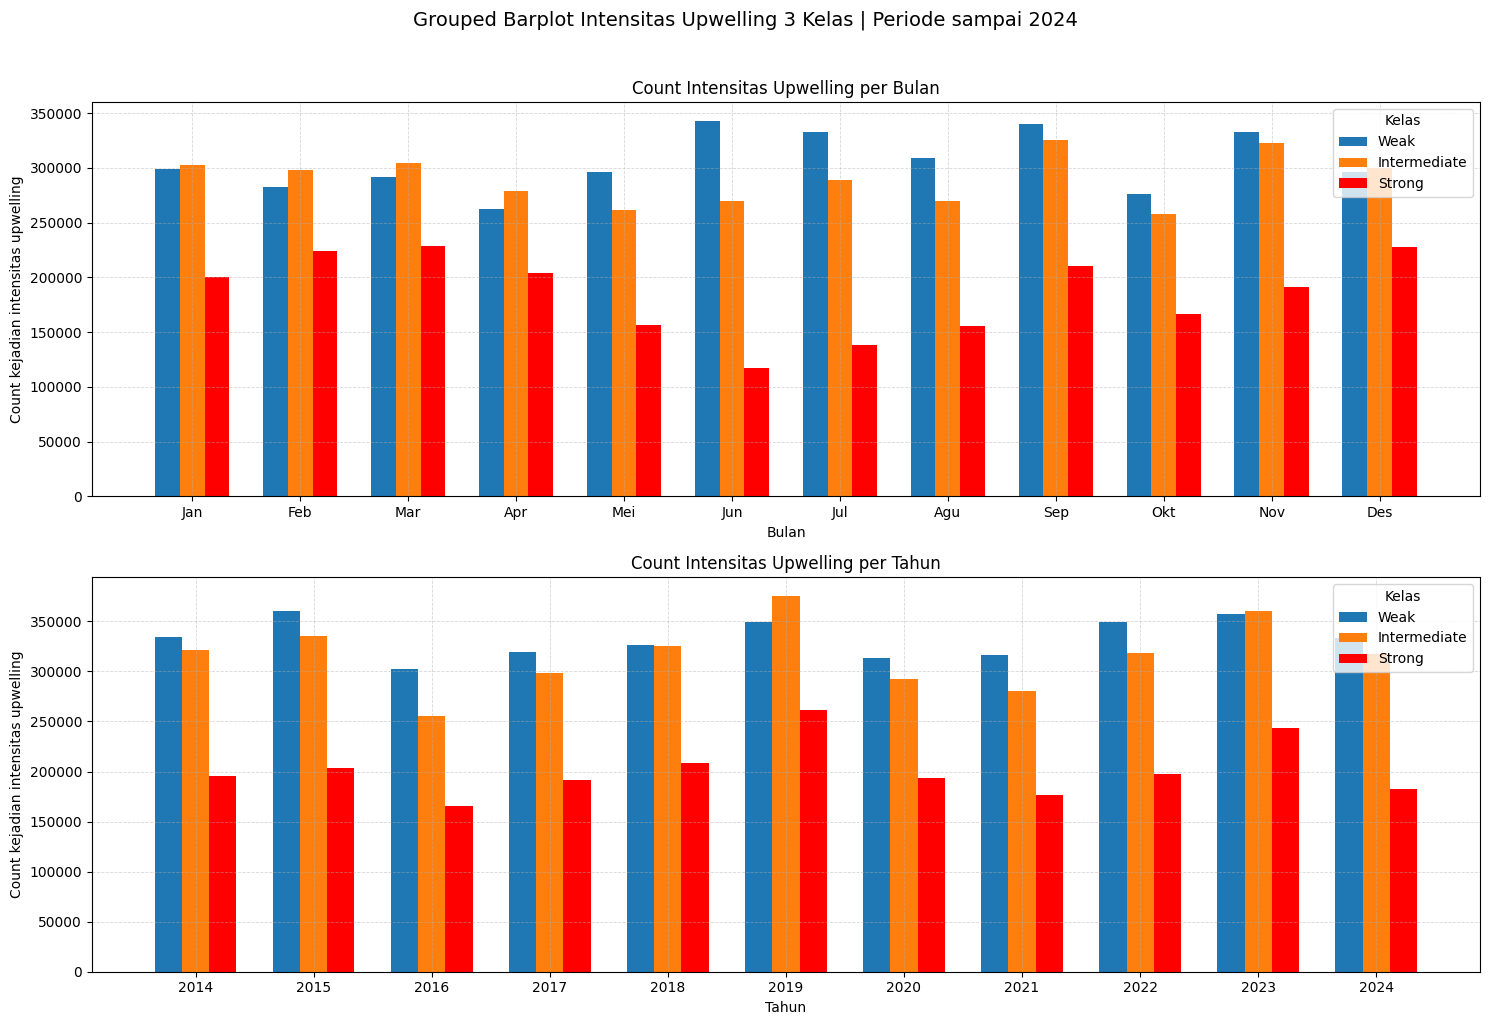

Jumlah grid inside WPP: 44054
Jumlah timestamp digunakan: 495
Tanggal awal: 2014-01-01
Tanggal akhir: 2024-12-26
Tahun yang dihitung: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Kelas yang ditampilkan: [1, 2, 3]


In [47]:
monthly_intensity_3class, yearly_intensity_3class = plot_upwelling_intensity_grouped_monthly_yearly_3class(
    ds_intensity=ds_intensity,
    mask_2d=mask_2d,
    intensity_var="upwelling_intensity",
    end_date="2024-12-31",
    value_mode="count",
    percentage_base="upwelling",
    show_values=False,
    save_path="barplot_intensitas_upwelling_3class_count_until_2024.png",
    figsize=(15, 10)
)

In [48]:
# save ds_intensity
ds_intensity.to_netcdf("/kaggle/working/ds_intensity_upwelling.nc")

In [49]:
ds_intensity

<xarray.Dataset> Size: 2GB
Dimensions:              (time: 496, lat: 408, lon: 432, rgb: 3,
                          eightbitcolor: 256)
Coordinates:
  * time                 (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat                  (lat) float32 2kB 6.979 6.938 6.896 ... -9.938 -9.979
  * lon                  (lon) float32 2kB 90.02 90.06 90.1 ... 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    qual_sst             (time, lat, lon) float32 350MB ...
    palette              (time, rgb, eightbitcolor) uint8 381kB ...
    sst                  (time, lat, lon) float64 699MB ...
    SST_max              (time, lat) float64 2MB nan nan nan nan ... nan nan nan
    SST_max_lon          (lat) float32 2kB nan nan nan nan ... nan nan nan nan
    uisst                (time, lat, lon) float64 699MB nan nan nan ... nan nan
    upwelling_valid      (time, lat, lon) int8 87MB 0 0 0 0 0 0 ... 0 0 0 0 0 0
    upwelling_intensity  (time, lat, lon) float32 350MB nan nan nan ... nan nan
Attributes: (12/65)
    product_name:                         AQUA_MODIS.20140101_20140108.L3m.8D...
    instrument:                           MODIS
    title:                                MODISA Level-3 Equidistant Cylindri...
    project:                              Ocean Biology Processing Group (NAS...
    platform:                             Aqua
    source:                               satellite observations from MODIS-Aqua
    ...                                   ...
    data_minimum:                         24.244999
    data_maximum:                         35.745
    SST_max_processing_note:              SST_max is defined as SSTwest, name...
    UISST_processing_note:                uisst was calculated by subtracting...
    upwelling_valid_processing_note:      upwelling_valid was computed from u...
    upwelling_intensity_processing_note:  upwelling_intensity was classified ...

In [50]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


def plot_upwelling_strong_all_time(
    ds_intensity,
    intensity_var="upwelling_intensity",
    strong_class=3,
    min_count=3,
    mask_2d=None,
    save_path=None,
    figsize=(10, 8)
):
    """
    Plot peta akumulatif kejadian upwelling strong sepanjang waktu.

    Hanya menampilkan piksel yang memiliki jumlah kejadian
    strong >= min_count.

    Parameter
    ---------
    ds_intensity : xarray.Dataset
        Dataset yang memiliki variabel upwelling_intensity.

    intensity_var : str
        Nama variabel intensitas upwelling.

    strong_class : int
        Nilai kelas untuk strong upwelling.
        Default = 3.

    min_count : int
        Ambang minimum jumlah kejadian strong agar titik ditampilkan.
        Default = 3.

    mask_2d : numpy.ndarray, xarray.DataArray, atau None
        Mask inside WPP (lat, lon). Jika None, akan diinfer dari data.

    save_path : str atau None
        Path untuk menyimpan plot PNG.

    figsize : tuple
        Ukuran figure.

    Return
    ------
    strong_sum : xarray.DataArray
        Jumlah kejadian upwelling strong pada tiap piksel.
    """

    # ========================================================
    # 1. Validasi input
    # ========================================================
    if intensity_var not in ds_intensity.data_vars:
        raise ValueError(
            f"Variabel '{intensity_var}' tidak ditemukan di ds_intensity."
        )

    intensity = ds_intensity[intensity_var].transpose("time", "lat", "lon")
    lats = ds_intensity["lat"].values
    lons = ds_intensity["lon"].values

    # ========================================================
    # 2. Tentukan mask inside WPP
    # ========================================================
    if mask_2d is not None:

        if isinstance(mask_2d, xr.DataArray):
            inside_wpp_da = (
                mask_2d
                .transpose("lat", "lon")
                .astype(bool)
            )

            inside_wpp_da, _ = xr.align(
                inside_wpp_da,
                intensity.isel(time=0, drop=True),
                join="exact"
            )

        else:
            mask_2d = np.asarray(mask_2d).astype(bool)

            if mask_2d.shape != (len(lats), len(lons)):
                raise ValueError(
                    f"Shape mask_2d {mask_2d.shape} tidak sesuai dengan "
                    f"dimensi lat-lon ({len(lats)}, {len(lons)})."
                )

            inside_wpp_da = xr.DataArray(
                mask_2d,
                coords={"lat": ds_intensity["lat"], "lon": ds_intensity["lon"]},
                dims=("lat", "lon")
            )

    else:
        inside_wpp_da = np.isfinite(intensity).any(dim="time")

    # ========================================================
    # 3. Hitung jumlah kejadian upwelling strong
    # ========================================================
    strong_sum = (intensity == strong_class).sum(dim="time")

    # hanya area inside WPP
    strong_sum = strong_sum.where(inside_wpp_da)

    # hanya tampilkan titik dengan jumlah kejadian >= min_count
    strong_plot = strong_sum.where(strong_sum >= min_count)

    # ========================================================
    # 4. Plot
    # ========================================================
    lon2d, lat2d = np.meshgrid(lons, lats)

    fig, ax = plt.subplots(figsize=figsize)

    mesh = ax.pcolormesh(
        lon2d,
        lat2d,
        strong_plot.values,
        shading="auto",
        cmap="Reds"
    )

    # outline WPP
    ax.contour(
        lon2d,
        lat2d,
        inside_wpp_da.values.astype(int),
        levels=[0.5],
        colors="black",
        linewidths=0.8
    )

    cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(
        f"Jumlah kejadian upwelling strong (hanya tampil jika ≥ {min_count})"
    )

    ax.set_title(f"Distribusi Upwelling Strong (2014-2024)")
    ax.set_xlabel("Longitude [degrees_east]")
    ax.set_ylabel("Latitude [degrees_north]")

    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.5
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot disimpan ke: {save_path}")

    plt.show()

    return strong_sum

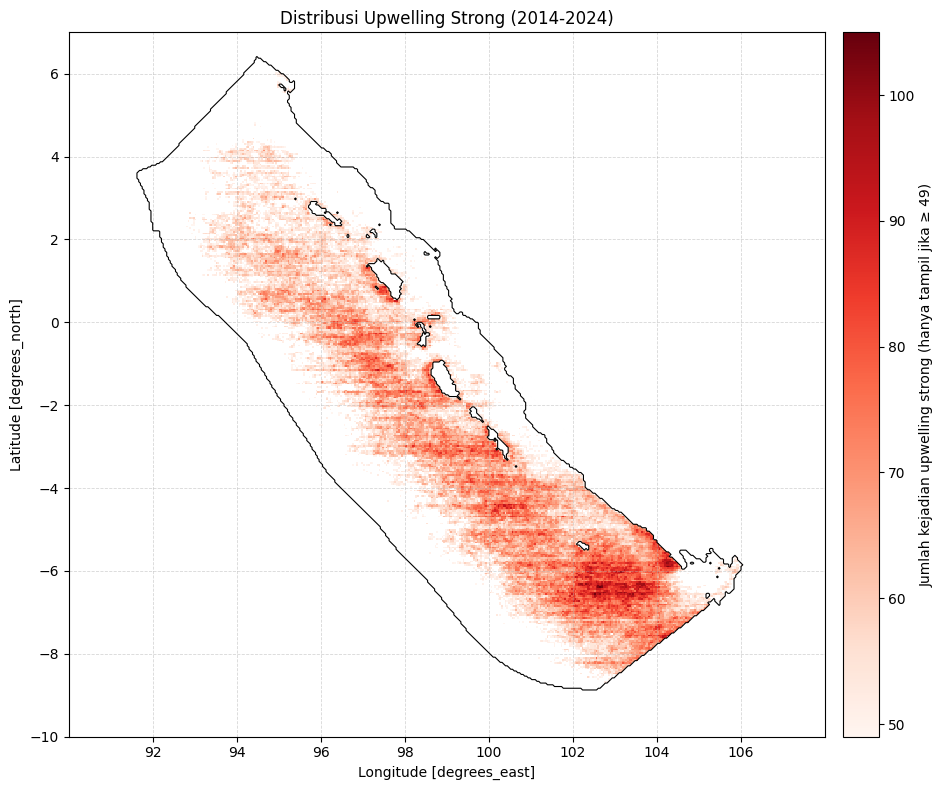

In [51]:
strong_sum = plot_upwelling_strong_all_time(
    ds_intensity=ds_intensity,
    intensity_var="upwelling_intensity",
    strong_class=3,
    min_count=49,
    mask_2d=mask_2d
)

In [52]:
# Hitung jumlah kejadian strong upwelling pada setiap piksel
strong_count = (
    ds_intensity["upwelling_intensity"] == 3
).sum(dim="time")

# Hanya piksel inside WPP
strong_count = strong_count.where(mask_2d)

# Ubah menjadi Series dan ambil piksel yang pernah strong
strong_count_series = (
    strong_count
    .to_series()
    .dropna()
)

strong_count_positive = strong_count_series[
    strong_count_series > 0
]

# Statistik deskriptif
deskripsi_strong = strong_count_positive.describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

print("Deskripsi count strong upwelling:")
print(deskripsi_strong)

Deskripsi count strong upwelling:
count    43687.000000
mean        50.848445
std         16.886216
min          1.000000
10%         29.000000
25%         39.000000
50%         52.000000
75%         63.000000
90%         72.000000
95%         77.000000
99%         87.000000
max        105.000000
Name: upwelling_intensity, dtype: float64


## SEBARAN INTENSITAS

In [53]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def plot_upwelling_intensity_all_time(
    ds_intensity,
    intensity_var="upwelling_intensity",
    min_count=50,
    mask_2d=None,
    save_path=None,
    figsize=(18, 6)
):
    """
    Plot 3 peta akumulatif kejadian upwelling:
    weak, intermediate, dan strong
    dalam layout 1 row x 3 col.

    Hanya menampilkan piksel dengan jumlah kejadian >= min_count.

    Kelas:
    1 = weak
    2 = intermediate
    3 = strong

    Parameter
    ---------
    ds_intensity : xarray.Dataset
        Dataset yang memiliki variabel upwelling_intensity.

    intensity_var : str
        Nama variabel intensitas upwelling.

    min_count : int
        Ambang minimum jumlah kejadian agar titik ditampilkan.
        Default = 50.

    mask_2d : numpy.ndarray, xarray.DataArray, atau None
        Mask inside WPP (lat, lon). Jika None, akan diinfer dari data.

    save_path : str atau None
        Path untuk menyimpan plot PNG.

    figsize : tuple
        Ukuran figure.

    Return
    ------
    result_dict : dict
        Dictionary berisi DataArray count untuk weak,
        intermediate, dan strong.
    """

    # ========================================================
    # 1. Validasi input
    # ========================================================
    if intensity_var not in ds_intensity.data_vars:
        raise ValueError(
            f"Variabel '{intensity_var}' tidak ditemukan di ds_intensity."
        )

    intensity = ds_intensity[intensity_var].transpose("time", "lat", "lon")
    lats = ds_intensity["lat"].values
    lons = ds_intensity["lon"].values

    # ========================================================
    # 2. Tentukan mask inside WPP
    # ========================================================
    if mask_2d is not None:

        if isinstance(mask_2d, xr.DataArray):
            inside_wpp_da = (
                mask_2d
                .transpose("lat", "lon")
                .astype(bool)
            )

            inside_wpp_da, _ = xr.align(
                inside_wpp_da,
                intensity.isel(time=0, drop=True),
                join="exact"
            )

        else:
            mask_2d = np.asarray(mask_2d).astype(bool)

            if mask_2d.shape != (len(lats), len(lons)):
                raise ValueError(
                    f"Shape mask_2d {mask_2d.shape} tidak sesuai dengan "
                    f"dimensi lat-lon ({len(lats)}, {len(lons)})."
                )

            inside_wpp_da = xr.DataArray(
                mask_2d,
                coords={"lat": ds_intensity["lat"], "lon": ds_intensity["lon"]},
                dims=("lat", "lon")
            )

    else:
        inside_wpp_da = np.isfinite(intensity).any(dim="time")

    # ========================================================
    # 3. Hitung jumlah kejadian untuk tiap kelas
    # ========================================================
    weak_sum = (intensity == 1).sum(dim="time").where(inside_wpp_da)
    intermediate_sum = (intensity == 2).sum(dim="time").where(inside_wpp_da)
    strong_sum = (intensity == 3).sum(dim="time").where(inside_wpp_da)

    # Hanya tampilkan count >= min_count
    weak_plot = weak_sum.where(weak_sum >= min_count)
    intermediate_plot = intermediate_sum.where(intermediate_sum >= min_count)
    strong_plot = strong_sum.where(strong_sum >= min_count)

    # ========================================================
    # 4. Siapkan grid dan colormap
    # ========================================================
    lon2d, lat2d = np.meshgrid(lons, lats)

    cmap_weak = plt.cm.Blues
    cmap_intermediate = LinearSegmentedColormap.from_list(
        "yellow_grad", ["#fff9c4", "#ffd600"]
    )
    cmap_strong = plt.cm.Reds

    plot_configs = [
        ("Weak Upwelling", weak_plot, cmap_weak),
        ("Intermediate Upwelling", intermediate_plot, cmap_intermediate),
        ("Strong Upwelling", strong_plot, cmap_strong),
    ]

    # ========================================================
    # 5. Plot 1 row x 3 col
    # ========================================================
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharex=True, sharey=True)

    for ax, (title, data_plot, cmap) in zip(axes, plot_configs):

        mesh = ax.pcolormesh(
            lon2d,
            lat2d,
            data_plot.values,
            shading="auto",
            cmap=cmap
        )

        # outline WPP
        ax.contour(
            lon2d,
            lat2d,
            inside_wpp_da.values.astype(int),
            levels=[0.5],
            colors="black",
            linewidths=0.8
        )

        cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
        cbar.set_label(f"Count kejadian (≥ {min_count})")

        ax.set_title(title)
        ax.set_xlabel("Longitude [degrees_east]")
        ax.grid(
            True,
            which="major",
            linestyle="--",
            linewidth=0.6,
            alpha=0.5
        )

    axes[0].set_ylabel("Latitude [degrees_north]")

    fig.suptitle(
        f"Distribusi Akumulatif Instesitas Upwelling",
        y=1.02,
        fontsize=13
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot disimpan ke: {save_path}")

    plt.show()

    result_dict = {
        "weak_sum": weak_sum,
        "intermediate_sum": intermediate_sum,
        "strong_sum": strong_sum
    }

    return result_dict

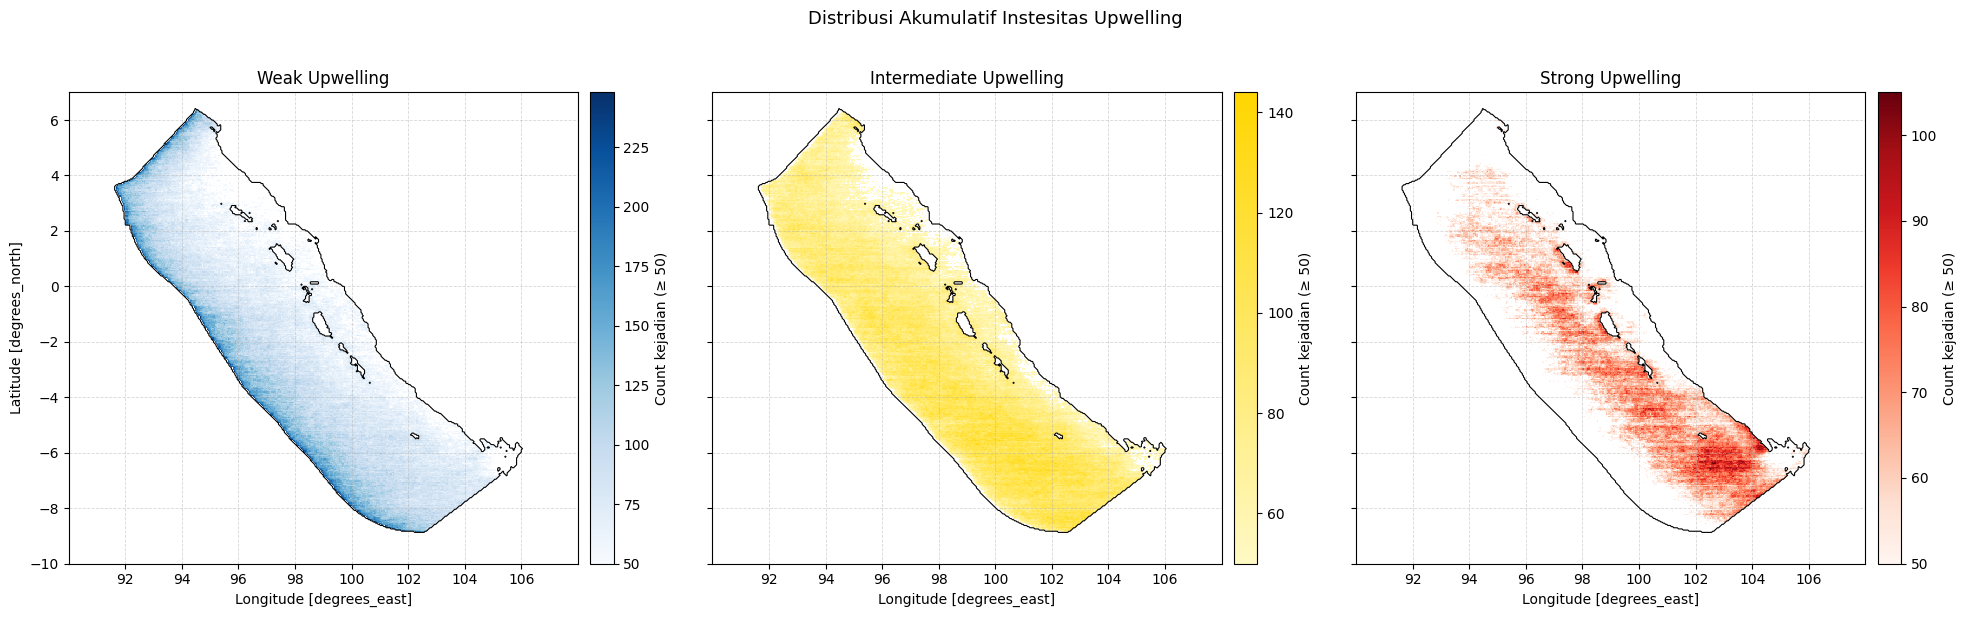

In [54]:
result_maps = plot_upwelling_intensity_all_time(
    ds_intensity=ds_intensity,
    intensity_var="upwelling_intensity",
    min_count=50,
    mask_2d=mask_2d,
    figsize=(20, 6)
)